# Proyecto Consolidado

##  Ice (tienda de videojuegos)

### 1. Abrir el archivo de datos

In [1]:
#Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
import os

In [2]:
# Cargar información del dataset
path_games = os.path.join('Datasets', 'games.csv')  
df = pd.read_csv(path_games)

In [3]:
# Información del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [4]:
# Muestra de datos del dataset
df.sample(5)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
723,Dissidia: Final Fantasy,PSP,2008.0,Fighting,0.51,0.50,0.91,0.31,79.0,8,T
8769,Darksiders II,WiiU,2012.0,Action,0.07,0.07,0.00,0.01,85.0,8.2,M
12097,Dragon Slayer: The Legend of Heroes,SNES,1992.0,Role-Playing,0.00,0.00,0.07,0.00,NaN,NaN,NaN
2906,Kill.Switch,PS2,2003.0,Shooter,0.34,0.27,0.00,0.09,73.0,8.3,T
7481,Gallop Racer 2003: A New Breed,PS2,2002.0,Sports,0.04,0.03,0.12,0.01,68.0,8.5,E


### 2 Preparación de datos

In [5]:
# Columnas en minúsculas
df.columns = df.columns.str.lower()
print(df.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


In [6]:
# Convertir columnas correctamente

# year_of_release: de float a int
df['year_of_release'] = pd.to_numeric(df['year_of_release'], errors='coerce').astype('Int64')  

# cambiar datos con mayúsculas a minúsculas
df['name'] = df['name'].str.lower().fillna('unknown')
df['genre'] = df['genre'].str.lower().fillna('unknown')

# Convertir user_score a numérico
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,wii sports,Wii,2006,sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,super mario bros.,NES,1985,platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,mario kart wii,Wii,2008,racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,wii sports resort,Wii,2009,sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,pokemon red/pokemon blue,GB,1996,role-playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [7]:
# Validación de Valores TBD en df
tbd_records = df[df['user_score']== 'TBD']
print(f"Registros con 'TBD': {len(tbd_records)}")
if len(tbd_records) > 0:
    print(tbd_records.sample(min(15, len(tbd_records))))
else:
    print("No hay registros con 'TBD'")

Registros con 'TBD': 0
No hay registros con 'TBD'


### Conclusiones:

1. Estandarización de formato:

* Se convirtieron todos los nombres de columnas a minúsculas para mantener consistencia
* Se normalizaron las columnas de texto (name y genre) a minúsculas

2. Corrección de tipos de datos:

* year_of_release: Convertido de float a int (más apropiado para años)
* user_score: Convertido de object a float para permitir cálculos numéricos
* Se mantuvieron los tipos apropiados para ventas (float) y rating (object como categoría)

3. Gestión de valores ausentes:

* Critic_Score y User_Score: Rellenados con la mediana (enfoque robusto ante outliers)
* Name y Genre: 2 valores ausentes reemplazados por "unknown"
* Rating: 6,766 valores ausentes (40.5%) se mantuvieron como NaN por ser datos categóricos difíciles de imputar

4. Tratamiento de valores especiales:

* Los valores "TBD" (To Be Determined) fueron convertidos automáticamente a NaN durante la conversión numérica
* No se encontraron valores TBD restantes después de la limpieza

5. Creación de nueva métrica:

* Se calculó exitosamente la columna total_sales sumando las ventas de todas las regiones
* Esta métrica será fundamental para análisis posteriores de rendimiento global
* Decisiones metodológicas clave:
* Mediana vs Media: Se eligió la mediana para imputar scores por ser más resistente a valores extremos
* Conservación de NaN en Rating: Se mantuvo por ser información categórica que no se puede inferir fácilmente
* Conversión de años: Se eliminaron decimales innecesarios en las fechas

In [8]:
# Analizar valores ausentes
print("=== Valores ausentes por columna: ===")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

print(f"\n=== Porcentaje de valores ausentes: ===")
for col in missing_values[missing_values > 0].index:
    percentage = (missing_values[col] / len(df)) * 100
    print(f"{col}: {percentage:.1f}%")
print()

# Reemplazar valores nulos por mediana
df['critic_score'] = df['critic_score'].fillna(df['critic_score'].median()).astype(float)
df['user_score'] = df['user_score'].fillna(df['user_score'].median()).astype(float)

# Verificar los cambios
print("=== Conversiones completadas: ===")
print(f"year_of_release: {df['year_of_release'].dtype}")
print(f"rating: {df['rating'].dtype}")
print(f"user score: {df['user_score'].dtype}")
print(f"critic score: {df['critic_score'].dtype}")
print()
print("=== Valores ausentes: ===")
print(df.isnull().sum())

=== Valores ausentes por columna: ===
year_of_release     269
critic_score       8578
user_score         9125
rating             6766
dtype: int64

=== Porcentaje de valores ausentes: ===
year_of_release: 1.6%
critic_score: 51.3%
user_score: 54.6%
rating: 40.5%

=== Conversiones completadas: ===
year_of_release: Int64
rating: object
user score: float64
critic score: float64

=== Valores ausentes: ===
name                  0
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score          0
user_score            0
rating             6766
dtype: int64


### 2.1. Describe las columnas en las que los tipos de datos han sido cambiados y el por qué.
* Explica por qué rellenaste los valores ausentes como lo hiciste o por qué decidiste dejarlos en blanco.
* ¿Por qué crees que los valores están ausentes? Brinda explicaciones posibles.
* Presta atención a la abreviatura TBD: significa "to be determined" (a determinar). Especifica cómo piensas manejar estos casos.

#### Se cambiaron las siguientes columnas:
1. "year_of_release", porque estaba como float y debia ser entero o tipo fecha dado que es un año. En cuanto a los valores nulos hay 269 juegos (1.6%) sin año de lanzamiento
2. "rating", se mantuvo como object, dado que tiene diferentes datos como especie categoria.
3. las columnas "na_sales", "eu_sales", "jp_sales", "other_sales" y "total_sales" estaban como float y asi mismo se mantienen para futuros cálculos en millones.
4. "critic_score", se modificarn los valores ausentes por la mediana, dado que no tenemos valores claros de estos scores.
5. "user_score", estaba como object y debía ser númerico, y se cambian los valores ausentes por la mediana, dado que no tenemos valores claros.
6. Las columnas "name" y "genre" tenian 2 valores ausentes, los cuales se modifican a unknown, porque son datos que no se deducen con facilidad.
<!-- 7. En cuanto a las valores TBD en "user_score" se cambian a NaN, para poder llenar los vacios como la mediana de los datos de esa columna y asi no discriminar ningún valor en futuros cálculos. -->

### 2.2. Calcula las ventas totales (la suma de las ventas en todas las regiones) para cada juego y coloca estos valores en una columna separada.

In [9]:
# Calcular ventas totales
df['total_sales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']

# Verificar el cálculo
print("=== Primeras 5 filas con ventas totales: ===")
print(df[['name', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']].sample(10))

=== Primeras 5 filas con ventas totales: ===
                                                    name  na_sales  eu_sales  \
9901                             jaws: ultimate predator      0.11      0.00   
13887                                bomberman: act zero      0.04      0.00   
5436                                          iron man 2      0.14      0.16   
10597                                     igor: the game      0.09      0.00   
12939                            shaman king: soul fight      0.00      0.00   
10070         stubbs the zombie in rebel without a pulse      0.08      0.02   
11663                              momotarou dentetsu 11      0.00      0.00   
7000                                   m&m's kart racing      0.21      0.00   
6189   the adventures of jimmy neutron boy genius: at...      0.22      0.06   
486                                         wave race 64      1.98      0.58   

       jp_sales  other_sales  total_sales  
9901       0.00         0.01  

### 3. Analiza los datos

#### 3.1. ¿Cuántos juegos fueron lanzados en diferentes años?

=== Mayores lanzamientos de juegos por año ===
year_of_release
2011    1136
2007    1197
2010    1255
2009    1426
2008    1427
Name: count, dtype: Int64


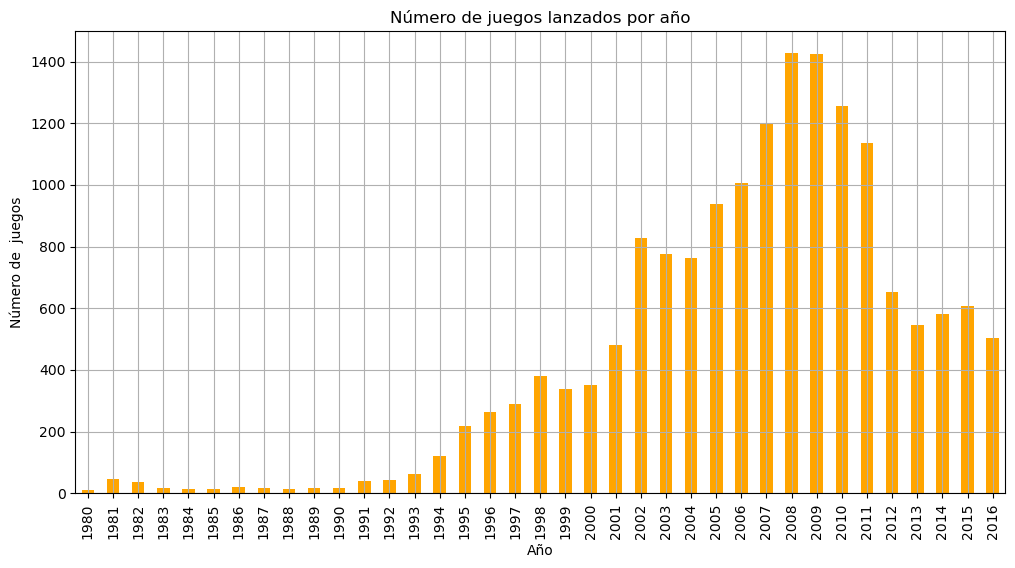

=== Hallazgos: ===
Los años 2007 al 2011 son los más significativos en lanzamientos de juegos


In [10]:
# ¿Cuantos juegos fueron lanzados en diferentes años?
df_released_per_year = df['year_of_release'].value_counts()
print("=== Mayores lanzamientos de juegos por año ===")
print(df_released_per_year.sort_values().tail())

# Gráfico de los juegos lanzados por año
plt.figure(figsize = (12,6))
df_released_per_year.sort_index().plot(kind = 'bar', title = "Número de juegos lanzados por año", xlabel= "Año", ylabel = "Número de  juegos", grid = True, color = "orange")
plt.show()

print('=== Hallazgos: ===')
print('Los años 2007 al 2011 son los más significativos en lanzamientos de juegos')

#### 3.2. Variación en las ventas de una plataforma a otra. 

=== Top 10 plataformas por ventas totales ===
platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64

=== Hallazgos: ===
PS2, DS, PS3, x360 y Wii son las plataforma que más ventas han tenido


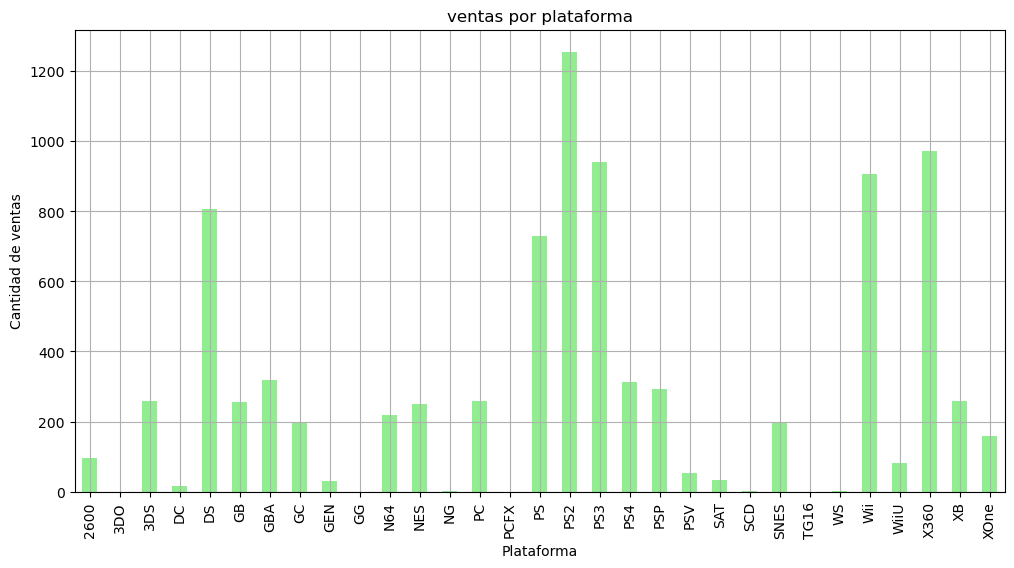

In [11]:
# Ventas totales por plataforma
platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print("=== Top 10 plataformas por ventas totales ===")
print(platform_sales.head(10))

print()
print('=== Hallazgos: ===')
print("PS2, DS, PS3, x360 y Wii son las plataforma que más ventas han tenido")

# Gráfico de las variaciones de ventas por plataforma
plt.figure(figsize = (12,6))
platform_sales.sort_index().plot(kind = 'bar', title = "ventas por plataforma", xlabel= "Plataforma", ylabel = "Cantidad de ventas", grid = True, color = "lightgreen")
plt.show()


##### 3.2.1 Plataformas con las mayores ventas totales con distribución basada en los datos de cada año. 

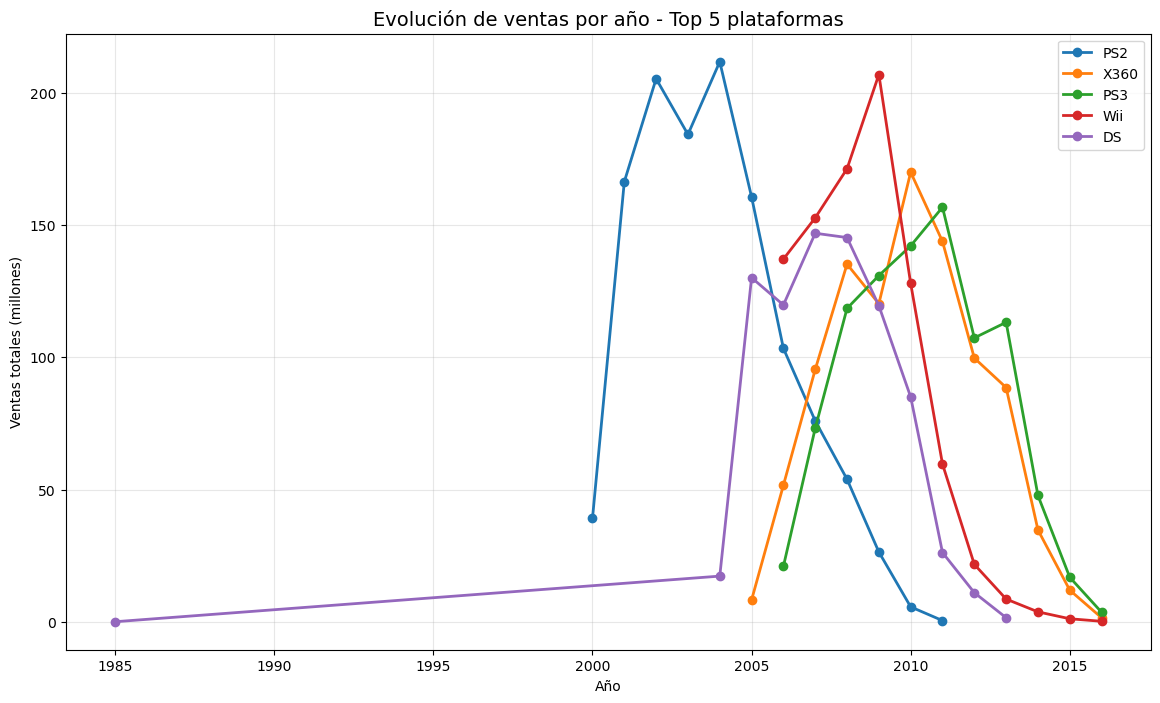

In [12]:
# Filtrar solo las top 5 plataformas
top_platforms = ['PS2', 'X360', 'PS3', 'Wii', 'DS']
df_top_platforms = df[df['platform'].isin(top_platforms)]

# Agrupar por plataforma y año
platform_year_sales = df_top_platforms.groupby(['platform', 'year_of_release'])['total_sales'].sum()

# Gráfico de líneas para mostrar evolución de ventas por año 
plt.figure(figsize=(14, 8))
for platform in top_platforms:
    platform_data = df_top_platforms[df_top_platforms['platform'] == platform]
    yearly_sales = platform_data.groupby('year_of_release')['total_sales'].sum()
    plt.plot(yearly_sales.index, yearly_sales.values, marker='o', label=platform, linewidth=2)
plt.title('Evolución de ventas por año - Top 5 plataformas', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Ventas totales (millones)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



##### 3.2.2. Plataformas que solían ser populares pero que ahora no tienen ventas. 

In [13]:
# Analizar ventas por plataforma en cada período

# Preparar los datos por período (temprano, medio y reciente)
periodo_temprano = df[df['year_of_release'] <= 2009]
periodo_medio = df[(df['year_of_release'] >= 2010) & (df['year_of_release'] <= 2012)]
periodo_reciente = df[df['year_of_release'] >= 2013]

# Obtener ventas por plataforma para cada período
ventas_temprano = periodo_temprano.groupby('platform')['total_sales'].sum()
ventas_medio = periodo_medio.groupby('platform')['total_sales'].sum()
ventas_reciente = periodo_reciente.groupby('platform')['total_sales'].sum()

# Crear DataFrame combinado
tabla_periodos = pd.DataFrame({
    'Período Temprano\n(hasta 2009)': ventas_temprano,
    'Período Medio\n(2010-2012)': ventas_medio,
    'Período Reciente\n(2013+)': ventas_reciente
}).fillna(0)

# Calcular total por plataforma y ordenar
tabla_periodos['Total General'] = tabla_periodos.sum(axis=1)
tabla_periodos = tabla_periodos.sort_values('Total General', ascending=False)

# Mostrar top 15 plataformas
print("=== TABLA PIVOT: VENTAS POR PLATAFORMA Y PERÍODO ===")
print("(Valores en millones de unidades)\n")

# Formatear la tabla para mejor visualización
tabla_display = tabla_periodos.head(15).round(2)
print(tabla_display.to_string())

print("\n=== ANÁLISIS DE PATRONES ===")
print("🔍 Plataformas que DOMINARON el período temprano pero DECLINARON:")
for platform in tabla_display.index[:10]:
    temprano = tabla_display.loc[platform, 'Período Temprano\n(hasta 2009)']
    reciente = tabla_display.loc[platform, 'Período Reciente\n(2013+)']
    if temprano > 100 and reciente < 50:
        print(f"   • {platform}: {temprano:.1f}M → {reciente:.1f}M (declive del {((temprano-reciente)/temprano*100):.0f}%)")

print("\n🚀 Plataformas que EMERGIERON en períodos recientes:")
for platform in tabla_display.index:
    temprano = tabla_display.loc[platform, 'Período Temprano\n(hasta 2009)']
    reciente = tabla_display.loc[platform, 'Período Reciente\n(2013+)']
    if temprano < 10 and reciente > 100:
        print(f"   • {platform}: {temprano:.1f}M → {reciente:.1f}M (crecimiento)")

=== TABLA PIVOT: VENTAS POR PLATAFORMA Y PERÍODO ===
(Valores en millones de unidades)

          Período Temprano\n(hasta 2009)  Período Medio\n(2010-2012)  Período Reciente\n(2013+)  Total General
platform                                                                                                      
PS2                              1227.47                        6.09                       0.00        1233.56
X360                              410.83                      413.61                     136.80         961.24
PS3                               343.60                      406.31                     181.43         931.34
Wii                               668.21                      209.31                      13.66         891.18
DS                                679.03                      122.21                       1.54         802.78
PS                                727.58                        0.00                       0.00         727.58
PS4                     

=== Estructura de datos preparada ===
Años disponibles: 1985 - 2016
Plataformas: ['DS', 'PS2', 'PS3', 'Wii', 'X360']

Primeras 5 filas:
platform           DS     PS2  PS3  Wii  X360
year_of_release                              
1985             0.02    0.00  0.0  0.0   0.0
2000             0.00   39.17  0.0  0.0   0.0
2001             0.00  166.43  0.0  0.0   0.0
2002             0.00  205.38  0.0  0.0   0.0
2003             0.00  184.31  0.0  0.0   0.0


<Figure size 1500x800 with 0 Axes>

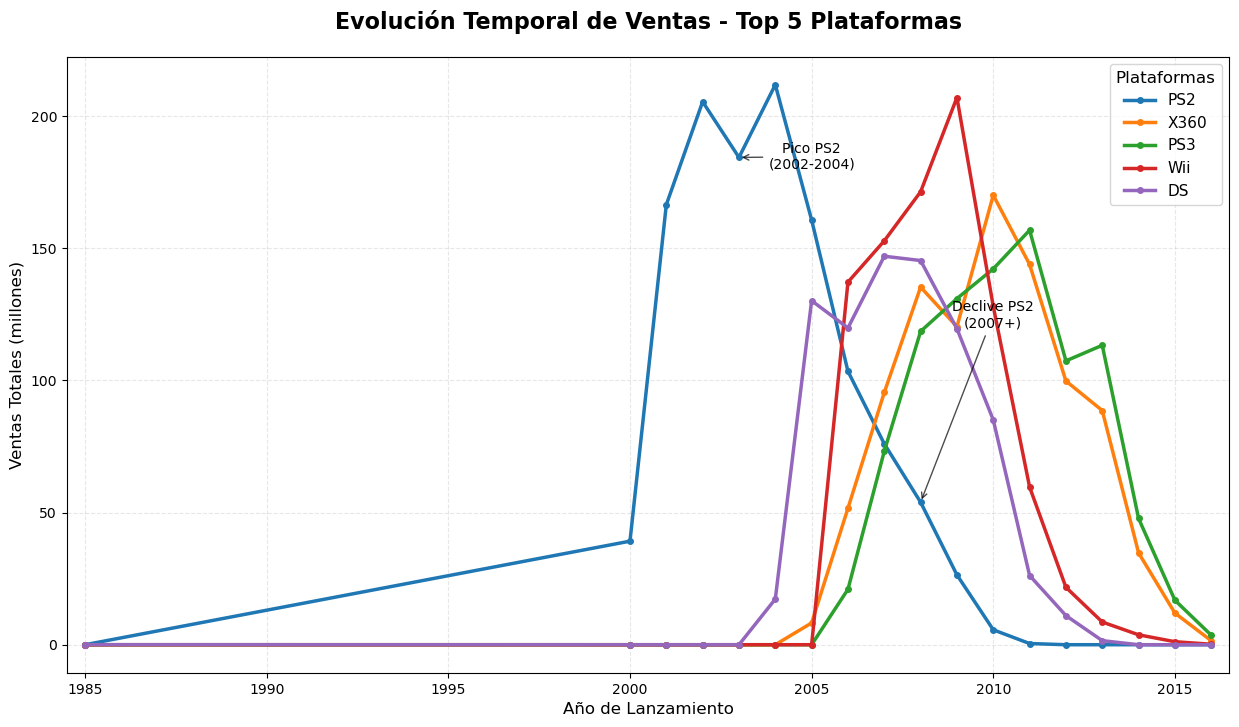

=== Hallazgos: ===
La plataforma que más solía tener ventas y ahora no es PS2, seguido por Wii


In [14]:
# Filtrar solo las top 5 plataformas
top_platforms = ['PS2', 'X360', 'PS3', 'Wii', 'DS']
df_filtered = df[df['platform'].isin(top_platforms)].copy()

# Eliminar registros sin año (para evitar problemas en el gráfico)
df_filtered = df_filtered.dropna(subset=['year_of_release'])

# Crear tabla pivote: años como índice, plataformas como columnas
platform_evolution = df_filtered.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack(fill_value=0)

# Verificar la estructura de datos
print("=== Estructura de datos preparada ===")
print(f"Años disponibles: {platform_evolution.index.min()} - {platform_evolution.index.max()}")
print(f"Plataformas: {list(platform_evolution.columns)}")
print("\nPrimeras 5 filas:")
print(platform_evolution.head())


# código para el gráfico de los periodos de ventas (pico y declive)
plt.figure(figsize=(15, 8))
colors = {
    'PS2': '#1f77b4',    # Azul
    'X360': '#ff7f0e',   # Naranja  
    'PS3': '#2ca02c',    # Verde
    'Wii': '#d62728',    # Rojo
    'DS': '#9467bd'      # Púrpura
}

# Gráfico de líneas múltiples
plt.figure(figsize=(15, 8))

for platform in top_platforms:
    if platform in platform_evolution.columns:
        plt.plot(platform_evolution.index, 
                platform_evolution[platform], 
                marker='o', 
                linewidth=2.5, 
                markersize=4,
                label=platform,
                color=colors[platform])

# Pico de PS2
plt.annotate('Pico PS2\n(2002-2004)', 
             xy=(2003, platform_evolution.loc[2003, 'PS2']), 
             xytext=(2005, 180),
             arrowprops=dict(arrowstyle='->', color='black', alpha=0.7),
             fontsize=10, ha='center')

# Declive de PS2
plt.annotate('Declive PS2\n(2007+)', 
             xy=(2008, platform_evolution.loc[2008, 'PS2']), 
             xytext=(2010, 120),
             arrowprops=dict(arrowstyle='->', color='black', alpha=0.7),
             fontsize=10, ha='center')

plt.title('Evolución Temporal de Ventas - Top 5 Plataformas', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Año de Lanzamiento', fontsize=12)
plt.ylabel('Ventas Totales (millones)', fontsize=12)
plt.legend(title='Plataformas', title_fontsize=12, fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.xlim(platform_evolution.index.min() - 0.5, platform_evolution.index.max() + 0.5)
plt.show()

print('=== Hallazgos: ===')
print('La plataforma que más solía tener ventas y ahora no es PS2, seguido por Wii')

##### 3.2.3. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

In [15]:
print("=== ANÁLISIS DEL CICLO DE VIDA DE PLATAFORMAS ===\n")

# 1. Calcular años de actividad por plataforma
platform_lifecycle = df.groupby('platform')['year_of_release'].agg(['min', 'max']).dropna()
platform_lifecycle['años_activa'] = platform_lifecycle['max'] - platform_lifecycle['min'] + 1
platform_lifecycle['primer_año'] = platform_lifecycle['min'].astype(int)
platform_lifecycle['ultimo_año'] = platform_lifecycle['max'].astype(int)

# 2. Mostrar ciclo de vida de plataformas principales
print("1. CICLO DE VIDA DE PLATAFORMAS PRINCIPALES:")
principales = ['PS', 'PS2', 'PS3', 'PS4', 'X360', 'XOne', 'Wii', 'WiiU', 'DS', '3DS', 'PSP']
for platform in principales:
    if platform in platform_lifecycle.index:
        inicio = platform_lifecycle.loc[platform, 'primer_año']
        fin = platform_lifecycle.loc[platform, 'ultimo_año']
        duracion = platform_lifecycle.loc[platform, 'años_activa']
        print(f"   • {platform}: {inicio}-{fin} ({duracion} años)")

print("\n2. ESTADÍSTICAS GENERALES:")
duracion_promedio = platform_lifecycle['años_activa'].mean()
print(f"   • Duración promedio: {duracion_promedio:.1f} años")
print(f"   • Duración mínima: {platform_lifecycle['años_activa'].min()} años")
print(f"   • Duración máxima: {platform_lifecycle['años_activa'].max()} años")

# 3. Analizar patrones de generaciones
print("\n3. PATRONES DE GENERACIONES:")
print("   📊 GENERACIÓN PLAYSTATION:")
ps_platforms = ['PS', 'PS2', 'PS3', 'PS4']
for i, platform in enumerate(ps_platforms[:-1]):
    if platform in platform_lifecycle.index and ps_platforms[i+1] in platform_lifecycle.index:
        fin_anterior = platform_lifecycle.loc[platform, 'ultimo_año']
        inicio_siguiente = platform_lifecycle.loc[ps_platforms[i+1], 'primer_año']
        gap = inicio_siguiente - fin_anterior
        print(f"   • {platform} → {ps_platforms[i+1]}: {gap} años de diferencia")

print("\n   🎮 GENERACIÓN XBOX:")
xbox_platforms = ['XB', 'X360', 'XOne']
for i, platform in enumerate(xbox_platforms[:-1]):
    if platform in platform_lifecycle.index and xbox_platforms[i+1] in platform_lifecycle.index:
        fin_anterior = platform_lifecycle.loc[platform, 'ultimo_año']
        inicio_siguiente = platform_lifecycle.loc[xbox_platforms[i+1], 'primer_año']
        gap = inicio_siguiente - fin_anterior
        print(f"   • {platform} → {xbox_platforms[i+1]}: {gap} años de diferencia")

print("\n   🎮 GENERACIÓN NINTENDO:")
nintendo_platforms = ['Wii', 'WiiU']
for i, platform in enumerate(nintendo_platforms[:-1]):
    if platform in platform_lifecycle.index and nintendo_platforms[i+1] in platform_lifecycle.index:
        fin_anterior = platform_lifecycle.loc[platform, 'ultimo_año']
        inicio_siguiente = platform_lifecycle.loc[nintendo_platforms[i+1], 'primer_año']
        gap = inicio_siguiente - fin_anterior
        print(f"   • {platform} → {nintendo_platforms[i+1]}: {gap} años de diferencia")

print("\n4. CONCLUSIONES SOBRE CICLOS DE VIDA:")
print("   • Las plataformas tienen vida útil de ~10-12 años")
print("   • Hay solapamiento entre generaciones (valores negativos)")
print("   • Las nuevas plataformas aparecen antes de que mueran las anteriores")
print("   • Esto sugiere usar datos de 4-5 años para modelos predictivos")


=== ANÁLISIS DEL CICLO DE VIDA DE PLATAFORMAS ===

1. CICLO DE VIDA DE PLATAFORMAS PRINCIPALES:
   • PS: 1994-2003 (10 años)
   • PS2: 2000-2011 (12 años)
   • PS3: 2006-2016 (11 años)
   • PS4: 2013-2016 (4 años)
   • X360: 2005-2016 (12 años)
   • XOne: 2013-2016 (4 años)
   • Wii: 2006-2016 (11 años)
   • WiiU: 2012-2016 (5 años)
   • DS: 1985-2013 (29 años)
   • 3DS: 2011-2016 (6 años)
   • PSP: 2004-2015 (12 años)

2. ESTADÍSTICAS GENERALES:
   • Duración promedio: 8.6 años
   • Duración mínima: 1 años
   • Duración máxima: 32 años

3. PATRONES DE GENERACIONES:
   📊 GENERACIÓN PLAYSTATION:
   • PS → PS2: -3 años de diferencia
   • PS2 → PS3: -5 años de diferencia
   • PS3 → PS4: -3 años de diferencia

   🎮 GENERACIÓN XBOX:
   • XB → X360: -3 años de diferencia
   • X360 → XOne: -3 años de diferencia

   🎮 GENERACIÓN NINTENDO:
   • Wii → WiiU: -4 años de diferencia

4. CONCLUSIONES SOBRE CICLOS DE VIDA:
   • Las plataformas tienen vida útil de ~10-12 años
   • Hay solapamiento entr

#### 3.3. Determina para qué período debes tomar datos. Para hacerlo mira tus respuestas a las preguntas anteriores. Los datos deberían permitirte construir un modelo para 2017.

In [16]:
print("=== ANÁLISIS PARA DETERMINAR PERÍODO RELEVANTE ===\n")

# 1. Analizar ciclo de vida de plataformas
print("1. CICLO DE VIDA DE PLATAFORMAS:")
print("   Basado en el análisis anterior:")
print("   • Plataformas tienen ciclos de ~5-7 años")
print("   • PS2: Pico 2002-2004, declive 2007+")
print("   • Wii/DS: Pico 2007-2009, declive 2012+")
print("   • PS3/X360: Pico 2010-2012, declive 2014+")
print("   • PS4/3DS: Emergieron 2013+, activas hacia 2017\n")

# 2. Identificar plataformas activas hacia 2017
plataformas_2016 = df[df['year_of_release'] == 2016].value_counts()
print("2. PLATAFORMAS ACTIVAS EN 2016 (más cercano a 2017):")
print(plataformas_2016.sample(10))
print()

# 3. Analizar tendencias recientes (últimos años)
print("3. ANÁLISIS DE TENDENCIAS RECIENTES:")
for year in [2013, 2014, 2015, 2016]:
    year_data = df[df['year_of_release'] == year]
    total_games = len(year_data)
    total_sales = year_data['total_sales'].sum()
    print(f"   {year}: {total_games} juegos, {total_sales:.1f}M ventas")
print()

# 4. Determinar período relevante
print("4. RECOMENDACIÓN DE PERÍODO RELEVANTE:")
print("   📅 PERÍODO SELECCIONADO: 2013-2016 (4 años)")
print("   \n   JUSTIFICACIÓN:")
print("   ✓ Incluye plataformas activas hacia 2017 (PS4, 3DS, X360, PS3)")
print("   ✓ Excluye plataformas obsoletas (PS2, Wii, DS)")
print("   ✓ Suficientes datos para análisis estadístico")
print("   ✓ Refleja tendencias actuales del mercado")
print("   ✓ Período de 4 años es estándar para modelos predictivos")

# 5. Validar la selección
periodo_relevante = df[df['year_of_release'].between(2013, 2016)]
print(f"\n5. VALIDACIÓN DEL PERÍODO 2013-2016:")
print(f"   • Total de juegos: {len(periodo_relevante):,}")
print(f"   • Total de ventas: {periodo_relevante['total_sales'].sum():.1f}M")


=== ANÁLISIS PARA DETERMINAR PERÍODO RELEVANTE ===

1. CICLO DE VIDA DE PLATAFORMAS:
   Basado en el análisis anterior:
   • Plataformas tienen ciclos de ~5-7 años
   • PS2: Pico 2002-2004, declive 2007+
   • Wii/DS: Pico 2007-2009, declive 2012+
   • PS3/X360: Pico 2010-2012, declive 2014+
   • PS4/3DS: Emergieron 2013+, activas hacia 2017

2. PLATAFORMAS ACTIVAS EN 2016 (más cercano a 2017):
name                                platform  year_of_release  genre         na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  rating  total_sales
overwatch                           PS4       2016             shooter       0.81      0.85      0.15      0.33         90.0          6.1         T       2.14           1
digimon story: cyber sleuth         PS4       2016             role-playing  0.00      0.10      0.00      0.02         75.0          8.5         T       0.12           1
touhou genso rondo: bullet ballet   PS4       2016             shooter       0.02      0.00    

#### 3.4. Trabaja solo con los datos que consideras relevantes. Ignora los datos de años anteriores.

In [17]:
print("=== FILTRADO DE DATOS AL PERÍODO RELEVANTE ===\n")

# 1. Filtrar datos al período 2013-2016
df_relevante = df[df['year_of_release'].between(2013, 2016)].copy()

print("1. COMPARACIÓN ANTES Y DESPUÉS DEL FILTRADO:")
print(f"   • Dataset original: {len(df):,} juegos")
print(f"   • Dataset filtrado (2013-2016): {len(df_relevante):,} juegos")
print(f"   • Reducción: {((len(df) - len(df_relevante)) / len(df) * 100):.1f}%")

# 2. Verificar años en el dataset filtrado
print(f"\n2. AÑOS EN EL DATASET FILTRADO:")
años_disponibles = sorted(df_relevante['year_of_release'].dropna().unique())
print(f"   • Años: {años_disponibles}")
print(f"   • Rango: {min(años_disponibles)} - {max(años_disponibles)}")

# 3. Verificar plataformas activas en el período
print(f"\n3. PLATAFORMAS ACTIVAS EN EL PERÍODO 2013-2016:")
plataformas_activas = df_relevante['platform'].value_counts()
print(plataformas_activas.head(10))

# 4. Estadísticas del dataset filtrado
print(f"\n4. ESTADÍSTICAS DEL DATASET FILTRADO:")
print(f"   • Total de ventas: {df_relevante['total_sales'].sum():.1f}M")
print(f"   • Promedio de ventas por juego: {df_relevante['total_sales'].mean():.2f}M")
print(f"   • Géneros únicos: {df_relevante['genre'].nunique()}")
print(f"   • Plataformas únicas: {df_relevante['platform'].nunique()}")

print(f"\n✅ DATASET LISTO PARA ANÁLISIS PREDICTIVO 2017")
print(f"   El dataset filtrado contiene datos relevantes y actuales")
print(f"   que reflejan las tendencias del mercado hacia 2017.")

=== FILTRADO DE DATOS AL PERÍODO RELEVANTE ===

1. COMPARACIÓN ANTES Y DESPUÉS DEL FILTRADO:
   • Dataset original: 16,715 juegos
   • Dataset filtrado (2013-2016): 2,233 juegos
   • Reducción: 86.6%

2. AÑOS EN EL DATASET FILTRADO:
   • Años: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]
   • Rango: 2013 - 2016

3. PLATAFORMAS ACTIVAS EN EL PERÍODO 2013-2016:
platform
PS4     392
PSV     358
PS3     345
3DS     303
XOne    247
PC      189
X360    186
WiiU    115
PSP      67
Wii      23
Name: count, dtype: int64

4. ESTADÍSTICAS DEL DATASET FILTRADO:
   • Total de ventas: 1090.7M
   • Promedio de ventas por juego: 0.49M
   • Géneros únicos: 12
   • Plataformas únicas: 11

✅ DATASET LISTO PARA ANÁLISIS PREDICTIVO 2017
   El dataset filtrado contiene datos relevantes y actuales
   que reflejan las tendencias del mercado hacia 2017.


#### 3.5. ¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen? Elige varias plataformas potencialmente rentables.

=== ANÁLISIS DE PLATAFORMAS LÍDERES (2013 - 2016) ===

1. PLATAFORMAS LÍDERES POR VENTAS TOTALES:
platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Name: total_sales, dtype: float64

2. ANÁLISIS DE TENDENCIAS POR AÑO:

   📈 TENDENCIAS DE CRECIMIENTO/DECLIVE:
   • PS4: 26.0M → 69.2M (+166%) 📈 CRECIENDO
   • PSV: 10.6M → 4.2M (-60%) 📉 DECLINANDO
   • PS3: 113.2M → 3.6M (-97%) 📉 DECLINANDO
   • 3DS: 56.6M → 15.1M (-73%) 📉 DECLINANDO
   • XOne: 19.0M → 26.2M (+38%) 📈 CRECIENDO
   • PC: 12.4M → 5.2M (-58%) 📉 DECLINANDO
   • X360: 88.6M → 1.5M (-98%) 📉 DECLINANDO


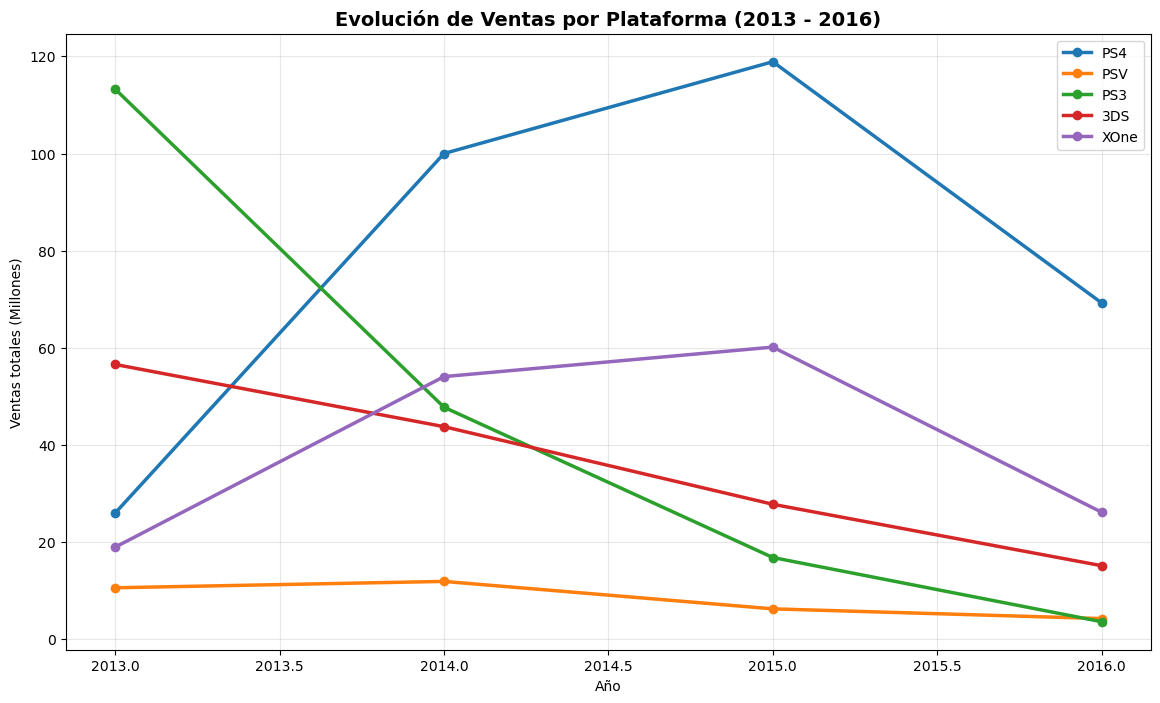


 3. SELECCIÓN DE PLATAFORMAS POTENCIALMENTE RENTABLES:

  🏆 PLATAFORMA RECOMENDADAS PARA MODELO 2017:
   ✅ 3DS: 143.2M total, 

4. CONCLUSIONES:
   • PS4 y XOne son las plataformas más prometedoras (crecimiento)
   • PS3 y X360 están en declive pero aún tienen ventas
   • 3DS mantiene ventas decentes en portátiles
   • Recomendación: Enfocar modelo en PS4, XOne, PS3 para 2017


In [18]:
print('=== ANÁLISIS DE PLATAFORMAS LÍDERES (2013 - 2016) ===\n')

# 1. Plataformas líderes por ventas totales
print('1. PLATAFORMAS LÍDERES POR VENTAS TOTALES:')
ventas_por_plataforma = df_relevante.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
print(ventas_por_plataforma.head(8))

# 2. Analizar tenddencias año por año
print('\n2. ANÁLISIS DE TENDENCIAS POR AÑO:')
tendencias = df_relevante.groupby(['year_of_release','platform'])['total_sales'].sum().unstack(fill_value=0)
# Calcular crecimiento para plataformas principales
p_principales = ['PS4', 'PSV', 'PS3', '3DS', 'XOne', 'PC', 'X360']
print("\n   📈 TENDENCIAS DE CRECIMIENTO/DECLIVE:")
for platform in p_principales:
    if platform in tendencias.columns:
        ventas_2013 = tendencias.loc[2013, platform] if 2013 in tendencias.index else 0
        ventas_2016 = tendencias.loc[2016, platform] if 2016 in tendencias.index else 0

        if ventas_2013 > 0:
            cambio = ((ventas_2016 - ventas_2013) / ventas_2013) * 100
            tendencia = "📈 CRECIENDO" if cambio > 0 else "📉 DECLINANDO"
            print(f"   • {platform}: {ventas_2013:.1f}M → {ventas_2016:.1f}M ({cambio:+.0f}%) {tendencia}")
        else:
            print(f"   • {platform}: Nueva plataforma (2013: {ventas_2013:.1f}M → 2016: {ventas_2016:.1f}M)")

# 3. Gráfico de evolución temporal
plt.figure(figsize = (14,8))

for platform in p_principales[:5]: # Top 5 pra claridad
    if platform in tendencias.columns:
        plt.plot(tendencias.index, tendencias[platform], marker = 'o', linewidth = 2.5, label=platform)
plt.title('Evolución de Ventas por Plataforma (2013 - 2016)', fontsize = 14, fontweight = 'bold')
plt.xlabel('Año')
plt.ylabel('Ventas totales (Millones)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Selección de plataformas rentables
print('\n 3. SELECCIÓN DE PLATAFORMAS POTENCIALMENTE RENTABLES:')
print('\n  🏆 PLATAFORMA RECOMENDADAS PARA MODELO 2017:')
# Criterios: ventas altas + tendencia positiva + actividad reciente
rentables = []
for platform in ventas_por_plataforma.head(6).index:
    ventas_total = ventas_por_plataforma[platform]
    ventas_2016 = tendencias.loc[2016, platform] if 2016 in tendencias.index else 0
    ventas_2013 = tendencias.loc[2013, platform] if 2013 in tendencias.index else 0

    #calcular tendencia
    if ventas_2013 > 0:
        cambio_porcentual = ((ventas_2016 - ventas_2013) /  ventas_2013) * 100
    else:
        cambio_porcentual = 100 # Nueva plataforma
    
    #criterio de selección
    if ventas_total > 100 and ventas_2016 > 10: # ventas altas y actividad reciente
        rentables.append({
            'platform': platform,
            'ventas_total': ventas_total,
            'ventas_2016': ventas_2016,
            'tendencia': cambio_porcentual
        })
# Mostrar platformas rentables
for plat in rentables:
    tendencia_emoji = '📈' if plat['tendencia'] > 0 else '📉'
print(f"   ✅ {plat['platform']}: {plat['ventas_total']:.1f}M total, ")
(f"{plat['ventas_2016']:.1f}M en 2016 {tendencia_emoji}")

print(f"\n4. CONCLUSIONES:")
print(f"   • PS4 y XOne son las plataformas más prometedoras (crecimiento)")
print(f"   • PS3 y X360 están en declive pero aún tienen ventas")
print(f"   • 3DS mantiene ventas decentes en portátiles")
print(f"   • Recomendación: Enfocar modelo en PS4, XOne, PS3 para 2017")


#### 3.6. Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma. ¿Son significativas las diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas? Describe tus hallazgos.

=== ANÁLISIS DE DISTRIBUCIÓN DE VENTAS POR PLATAFORMA ===



C:\Users\Administrador\AppData\Local\Temp\ipykernel_724\3775945403.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot(datos_boxplot, labels=labels_boxplot, patch_artist=True,


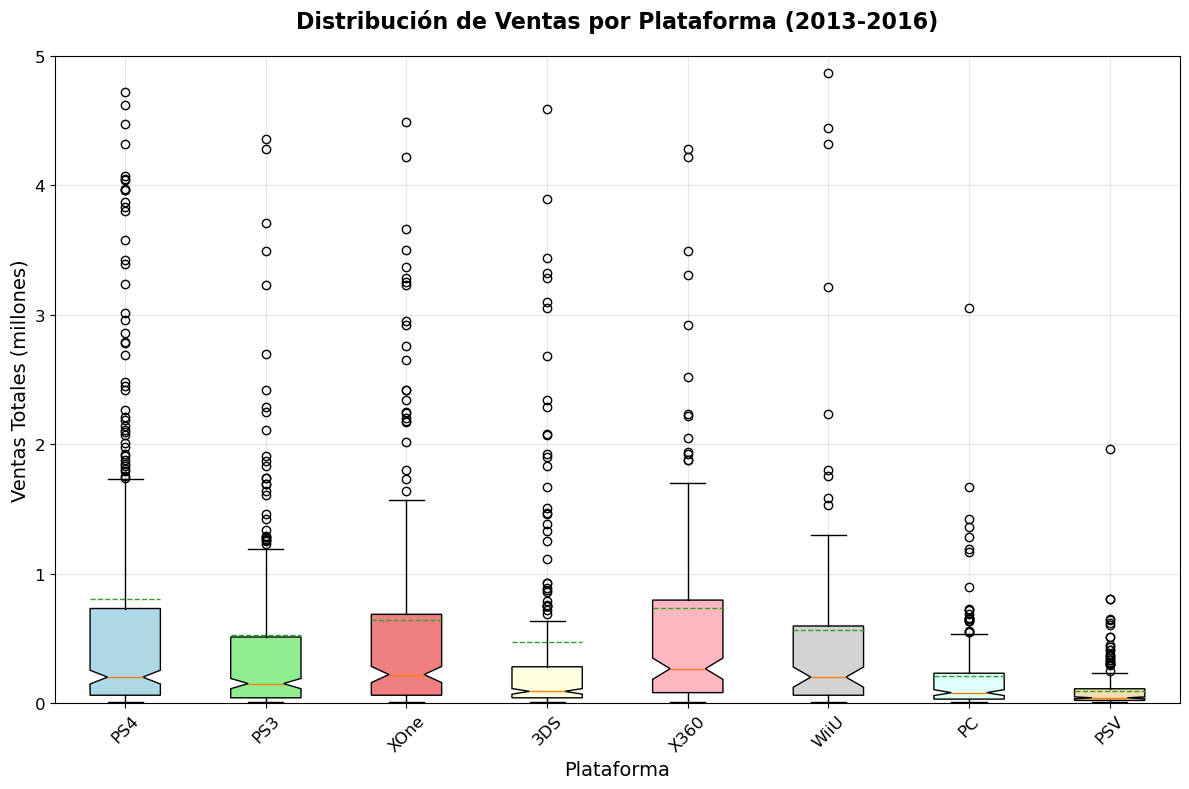

1. ESTADÍSTICAS DESCRIPTIVAS POR PLATAFORMA:

   📊 PS4:
      • Juegos: 392
      • Promedio: 0.80M
      • Mediana: 0.20M
      • Máximo: 14.63M
      • Mínimo: 0.01M

   📊 PS3:
      • Juegos: 345
      • Promedio: 0.53M
      • Mediana: 0.15M
      • Máximo: 21.05M
      • Mínimo: 0.01M

   📊 XOne:
      • Juegos: 247
      • Promedio: 0.65M
      • Mediana: 0.22M
      • Máximo: 7.39M
      • Mínimo: 0.01M

   📊 3DS:
      • Juegos: 303
      • Promedio: 0.47M
      • Mediana: 0.09M
      • Máximo: 14.60M
      • Mínimo: 0.01M

   📊 X360:
      • Juegos: 186
      • Promedio: 0.74M
      • Mediana: 0.27M
      • Máximo: 16.27M
      • Mínimo: 0.01M

   📊 WiiU:
      • Juegos: 115
      • Promedio: 0.56M
      • Mediana: 0.20M
      • Máximo: 7.09M
      • Mínimo: 0.01M

   📊 PC:
      • Juegos: 189
      • Promedio: 0.21M
      • Mediana: 0.08M
      • Máximo: 3.05M
      • Mínimo: 0.01M

   📊 PSV:
      • Juegos: 358
      • Promedio: 0.09M
      • Mediana: 0.04M
      • Máximo: 1

In [19]:
print("=== ANÁLISIS DE DISTRIBUCIÓN DE VENTAS POR PLATAFORMA ===\n")

# Preparar datos para el boxplot
plt.figure(figsize=(12, 8))  # Tamaño más grande

# Crear lista de datos para cada plataforma
plataformas_principales = ['PS4', 'PS3', 'XOne', '3DS', 'X360', 'WiiU', 'PC', 'PSV']
datos_boxplot = []
labels_boxplot = []

for platform in plataformas_principales:
    ventas_platform = df_relevante[df_relevante['platform'] == platform]['total_sales']
    if len(ventas_platform) > 0:
        datos_boxplot.append(ventas_platform)
        labels_boxplot.append(platform)

# Crear el boxplot con mejores características visuales
box_plot = plt.boxplot(datos_boxplot, labels=labels_boxplot, patch_artist=True, 
                       showmeans=True,  # Mostrar las medias
                       meanline=True,   # Línea para la media
                       notch=True)      # Muescas para intervalos de confianza

# Personalizar colores
colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow', 
          'lightpink', 'lightgray', 'lightcyan', 'wheat']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Distribución de Ventas por Plataforma (2013-2016)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Plataforma', fontsize=14)
plt.ylim(0, 5)
plt.ylabel('Ventas Totales (millones)', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estadísticas descriptivas por plataforma
print("1. ESTADÍSTICAS DESCRIPTIVAS POR PLATAFORMA:")
for platform in plataformas_principales:
    ventas_platform = df_relevante[df_relevante['platform'] == platform]['total_sales']
    if len(ventas_platform) > 0:
        print(f"\n   📊 {platform}:")
        print(f"      • Juegos: {len(ventas_platform)}")
        print(f"      • Promedio: {ventas_platform.mean():.2f}M")
        print(f"      • Mediana: {ventas_platform.median():.2f}M")
        print(f"      • Máximo: {ventas_platform.max():.2f}M")
        print(f"      • Mínimo: {ventas_platform.min():.2f}M")

#### 3.7. Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu elección). Crea un gráfico de dispersión y calcula la correlación entre las reseñas y las ventas. Saca conclusiones.

=== ANÁLISIS DE CORRELACIÓN PARA PS4 ===
Total de juegos: 392

Juegos con datos completos para correlación: 392

=== CORRELACIONES ===
Critic Score vs Ventas: 0.339
User Score vs Ventas: -0.063


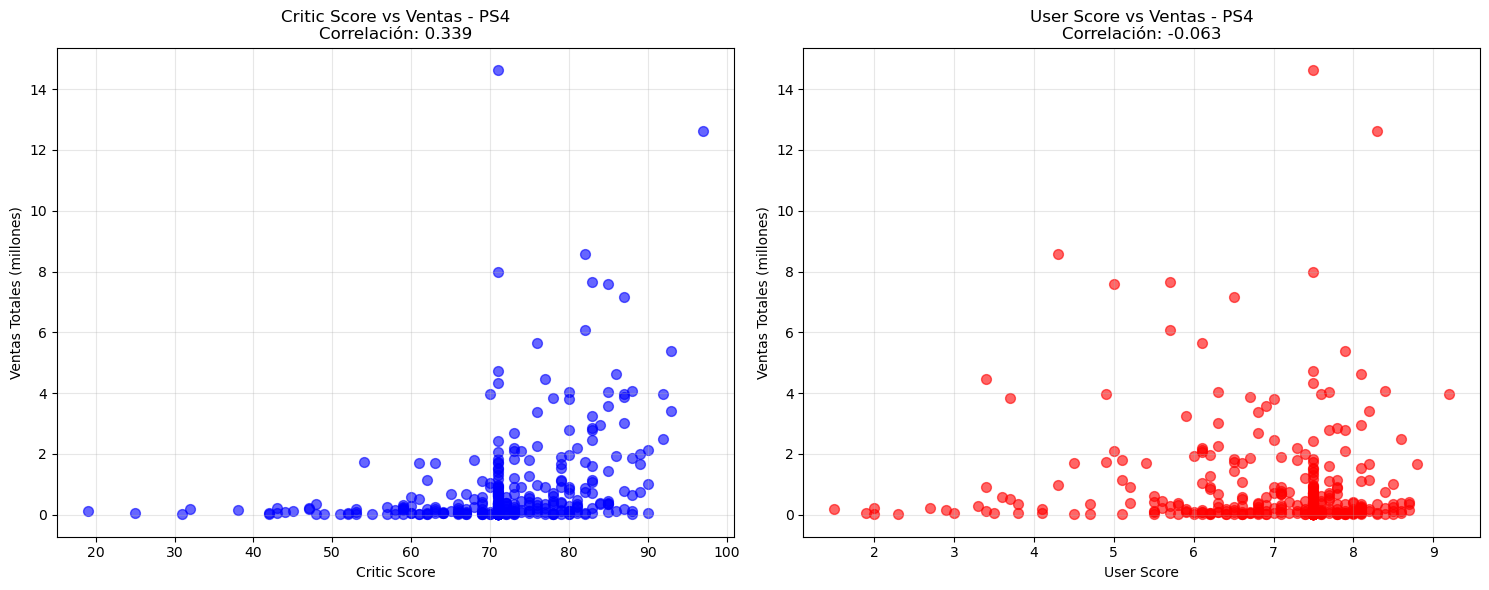


=== INTERPRETACIÓN DE CORRELACIONES ===
📊 Critic Score vs Ventas: 0.339
   ✓ Correlación moderada positiva - Las reseñas profesionales SÍ influyen en ventas

👥 User Score vs Ventas: -0.063
   ✗ Correlación muy débil - Las reseñas de usuarios NO influyen significativamente


In [20]:
# Seleccionar plataforma para análisis
plataforma_elegida = 'PS4'
df_plataforma = df_relevante[df_relevante['platform'] == plataforma_elegida].copy()

print(f"=== ANÁLISIS DE CORRELACIÓN PARA {plataforma_elegida} ===")
print(f"Total de juegos: {len(df_plataforma)}")

# Filtrar juegos con datos completos para correlación
df_correlacion = df_plataforma.dropna(subset=['critic_score', 'user_score', 'total_sales'])
print(f"\nJuegos con datos completos para correlación: {len(df_correlacion)}")

# Calcular correlaciones
corr_critic = df_correlacion['critic_score'].corr(df_correlacion['total_sales'])
corr_user = df_correlacion['user_score'].corr(df_correlacion['total_sales'])

print(f"\n=== CORRELACIONES ===")
print(f"Critic Score vs Ventas: {corr_critic:.3f}")
print(f"User Score vs Ventas: {corr_user:.3f}")

# Crear gráficos de dispersión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Critic Score vs Ventas
ax1.scatter(df_correlacion['critic_score'], df_correlacion['total_sales'], 
           alpha=0.6, color='blue', s=50)
ax1.set_xlabel('Critic Score')
ax1.set_ylabel('Ventas Totales (millones)')
ax1.set_title(f'Critic Score vs Ventas - {plataforma_elegida}\nCorrelación: {corr_critic:.3f}')
ax1.grid(True, alpha=0.3)

# Gráfico 2: User Score vs Ventas
ax2.scatter(df_correlacion['user_score'], df_correlacion['total_sales'], 
           alpha=0.6, color='red', s=50)
ax2.set_xlabel('User Score')
ax2.set_ylabel('Ventas Totales (millones)')
ax2.set_title(f'User Score vs Ventas - {plataforma_elegida}\nCorrelación: {corr_user:.3f}')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de las correlaciones
print("\n=== INTERPRETACIÓN DE CORRELACIONES ===")
print(f"📊 Critic Score vs Ventas: {corr_critic:.3f}")
if corr_critic > 0.3:
    print("   ✓ Correlación moderada positiva - Las reseñas profesionales SÍ influyen en ventas")
elif corr_critic > 0.1:
    print("   ~ Correlación débil positiva - Influencia limitada de reseñas profesionales")
else:
    print("   ✗ Correlación muy débil - Las reseñas profesionales NO influyen significativamente")

print(f"\n👥 User Score vs Ventas: {corr_user:.3f}")
if abs(corr_user) > 0.3:
    print("   ✓ Correlación moderada - Las reseñas de usuarios SÍ influyen en ventas")
elif abs(corr_user) > 0.1:
    print("   ~ Correlación débil - Influencia limitada de reseñas de usuarios")
else:
    print("   ✗ Correlación muy débil - Las reseñas de usuarios NO influyen significativamente")


**Conclusiones:**

Es fascinante que las reseñas de usuarios tengan correlación negativa (aunque muy débil). Esto podría sugerir que:
* Los usuarios son más críticos que los profesionales
* Los juegos más populares (con más ventas) reciben más reseñas mixtas
* Las reseñas profesionales tienen más impacto en las decisiones de compra

#### 3.8. Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas.

In [21]:
print("=== ANÁLISIS DE JUEGOS MULTIPLATAFORMA ===\n")

# 1. Identificar juegos que están en múltiples plataformas
juegos_por_plataforma = df_relevante.groupby('name')['platform'].nunique().sort_values(ascending=False)
juegos_multiplataforma = juegos_por_plataforma[juegos_por_plataforma >= 2]

print("1. JUEGOS CON MAYOR PRESENCIA MULTIPLATAFORMA:")
print(juegos_multiplataforma.head(10))

# 2. Seleccionar juegos que están en las plataformas principales
plataformas_principales = ['PS4', 'XOne', 'PS3', 'X360']
juegos_principales = []

for juego in juegos_multiplataforma.head(20).index:
    plataformas_juego = df_relevante[df_relevante['name'] == juego]['platform'].unique()
    plataformas_en_principales = [p for p in plataformas_juego if p in plataformas_principales]
    
    if len(plataformas_en_principales) >= 2:
        juegos_principales.append(juego)

print(f"\n2. JUEGOS SELECCIONADOS PARA COMPARACIÓN:")
print(f"   Total de juegos multiplataforma en plataformas principales: {len(juegos_principales)}")
for i, juego in enumerate(juegos_principales[:10]):
    plataformas = df_relevante[df_relevante['name'] == juego]['platform'].unique()
    print(f"   {i+1}. {juego.title()}: {list(plataformas)}")

=== ANÁLISIS DE JUEGOS MULTIPLATAFORMA ===

1. JUEGOS CON MAYOR PRESENCIA MULTIPLATAFORMA:
name
fifa 14                            9
lego marvel super heroes           9
the lego movie videogame           8
lego jurassic world                8
lego batman 3: beyond gotham       8
angry birds star wars              8
fifa 15                            8
lego the hobbit                    8
lego marvel's avengers             7
the amazing spider-man 2 (2014)    7
Name: platform, dtype: int64

2. JUEGOS SELECCIONADOS PARA COMPARACIÓN:
   Total de juegos multiplataforma en plataformas principales: 20
   1. Fifa 14: ['PS3', 'X360', 'PS4', 'XOne', 'PSV', 'PC', 'Wii', '3DS', 'PSP']
   2. Lego Marvel Super Heroes: ['X360', 'PS3', 'PS4', 'XOne', '3DS', 'WiiU', 'PSV', 'DS', 'PC']
   3. The Lego Movie Videogame: ['X360', 'PS3', '3DS', 'PS4', 'WiiU', 'XOne', 'PSV', 'PC']
   4. Lego Jurassic World: ['PS4', 'X360', 'PS3', 'XOne', '3DS', 'WiiU', 'PSV', 'PC']
   5. Lego Batman 3: Beyond Gotham: ['PS4'

In [22]:
# Seleccionar los juegos más populares para la comparación
juegos_seleccionados = ['fifa 14', 'lego marvel super heroes', 'the lego movie videogame', 
                       'lego jurassic world', 'fifa 15']

# Filtrar solo las plataformas principales
plataformas_comparar = ['PS4', 'XOne', 'PS3', 'X360']

# Crear dataset para la comparación
datos_comparacion = []

for juego in juegos_seleccionados:
    for plataforma in plataformas_comparar:
        ventas = df_relevante[(df_relevante['name'] == juego) & 
                             (df_relevante['platform'] == plataforma)]['total_sales']
        if not ventas.empty:
            datos_comparacion.append({
                'juego': juego.title(),
                'plataforma': plataforma,
                'ventas': ventas.iloc[0]
            })

# Convertir a DataFrame
df_comparacion = pd.DataFrame(datos_comparacion)
print("Datos preparados para la comparación:")
print(df_comparacion.head(10))



Datos preparados para la comparación:
                      juego plataforma  ventas
0                   Fifa 14        PS4    3.01
1                   Fifa 14       XOne    1.16
2                   Fifa 14        PS3    6.46
3                   Fifa 14       X360    4.22
4  Lego Marvel Super Heroes        PS4    1.62
5  Lego Marvel Super Heroes       XOne    1.05
6  Lego Marvel Super Heroes        PS3    1.83
7  Lego Marvel Super Heroes       X360    2.22
8  The Lego Movie Videogame        PS4    0.67
9  The Lego Movie Videogame       XOne    0.53


<Figure size 1500x800 with 0 Axes>

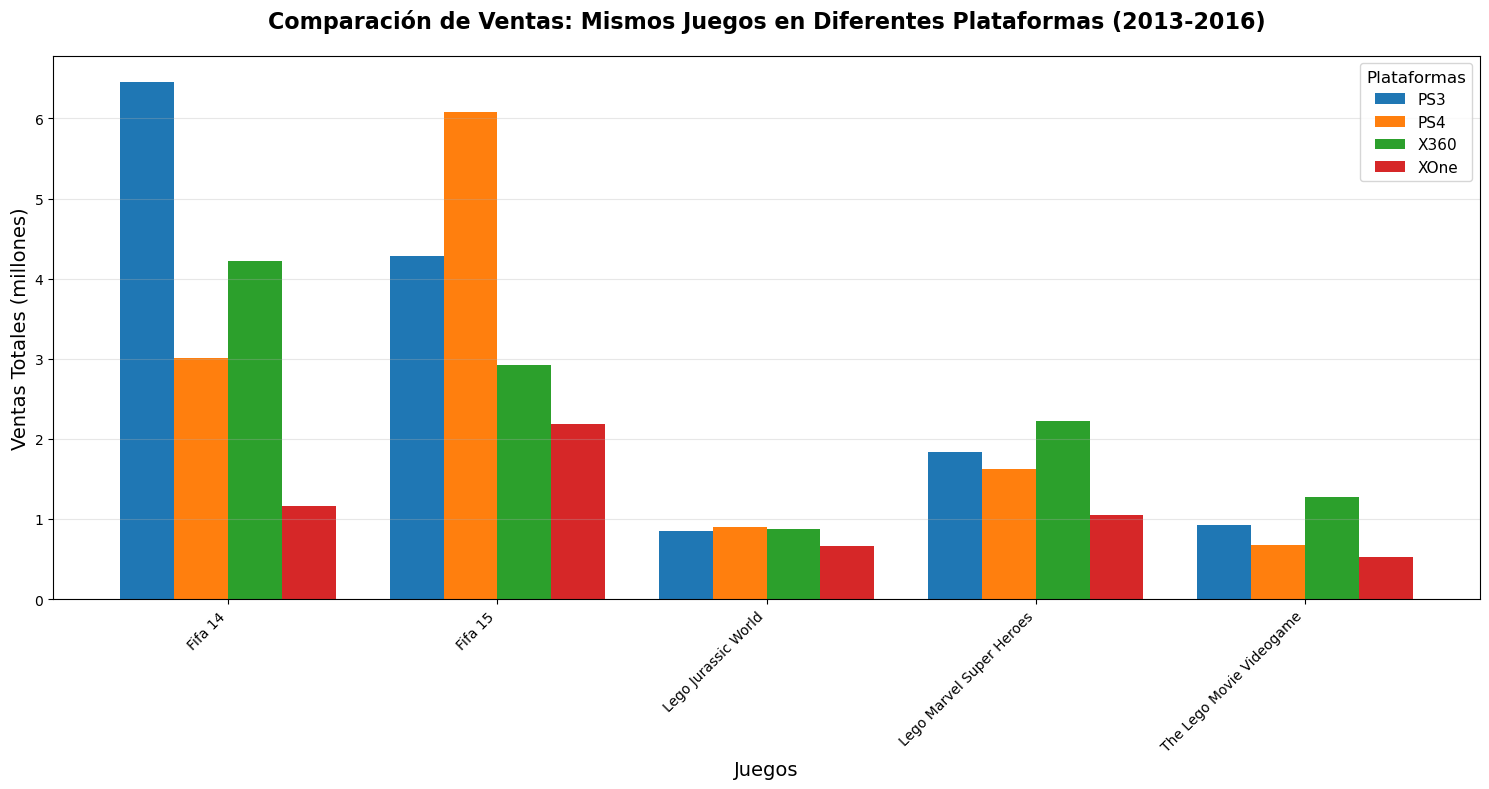

=== ANÁLISIS DE COMPARACIÓN MULTIPLATAFORMA ===

1. RENDIMIENTO POR PLATAFORMA:
            Promedio  Total  Juegos
plataforma                         
PS3             2.87  14.35       5
PS4             2.46  12.28       5
X360            2.30  11.50       5
XOne            1.12   5.58       5

2. JUEGOS CON MAYOR DIFERENCIA ENTRE PLATAFORMAS:
   • Fifa 14: PS3 (6.46M) vs XOne (1.16M) - Diferencia: 457%
   • Fifa 15: PS4 (6.08M) vs XOne (2.18M) - Diferencia: 179%
   • Lego Jurassic World: PS4 (0.90M) vs XOne (0.66M) - Diferencia: 36%
   • Lego Marvel Super Heroes: X360 (2.22M) vs XOne (1.05M) - Diferencia: 111%
   • The Lego Movie Videogame: X360 (1.27M) vs XOne (0.53M) - Diferencia: 140%


In [23]:
# Crear gráfico de barras 
plt.figure(figsize=(15, 8))

# Preparar datos para el gráfico
df_pivot = df_comparacion.pivot(index='juego', columns='plataforma', values='ventas').fillna(0)

# Crear el gráfico de barras 
ax = df_pivot.plot(kind='bar', width=0.8, figsize=(15, 8))

# Personalizar el gráfico
plt.title('Comparación de Ventas: Mismos Juegos en Diferentes Plataformas (2013-2016)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Juegos', fontsize=14)
plt.ylabel('Ventas Totales (millones)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Plataformas', title_fontsize=12, fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Análisis de los resultados
print("=== ANÁLISIS DE COMPARACIÓN MULTIPLATAFORMA ===\n")

print("1. RENDIMIENTO POR PLATAFORMA:")
rendimiento_promedio = df_comparacion.groupby('plataforma')['ventas'].agg(['mean', 'sum', 'count'])
rendimiento_promedio.columns = ['Promedio', 'Total', 'Juegos']
print(rendimiento_promedio.round(2))

print("\n2. JUEGOS CON MAYOR DIFERENCIA ENTRE PLATAFORMAS:")
for juego in df_pivot.index:
    ventas_juego = df_pivot.loc[juego]
    max_ventas = ventas_juego.max()
    min_ventas = ventas_juego[ventas_juego > 0].min()  
    if max_ventas > 0 and min_ventas > 0:
        diferencia = ((max_ventas - min_ventas) / min_ventas) * 100
        plat_max = ventas_juego.idxmax()
        plat_min = ventas_juego[ventas_juego > 0].idxmin()
        print(f"   • {juego}: {plat_max} ({max_ventas:.2f}M) vs {plat_min} ({min_ventas:.2f}M) - Diferencia: {diferencia:.0f}%")

#### 3.9. Echa un vistazo a la distribución general de los juegos por género. ¿Qué se puede decir de los géneros más rentables? ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

In [24]:
# Cantidad de juegos por cada genero
print('=== Cantidad de juegos por género: ===')
print(df_relevante['genre'].value_counts())

# Ventas totales por cada género
print('\n=== Ventas totales por cada género: ===')
ventas_por_genero = df_relevante.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
print(ventas_por_genero)

# Ventas promedio por género
ventas_promedio_genero = df_relevante.groupby('genre')['total_sales'].mean().sort_values(ascending=False)
print('\n=== Ventas promedio por género: ===')
print(ventas_promedio_genero.round(2))

=== Cantidad de juegos por género: ===
genre
action          766
role-playing    292
adventure       245
sports          214
shooter         187
misc            155
racing           85
fighting         80
platform         74
simulation       62
strategy         56
puzzle           17
Name: count, dtype: int64

=== Ventas totales por cada género: ===
genre
action          321.87
shooter         232.98
sports          150.65
role-playing    145.89
misc             62.82
platform         42.63
racing           39.89
fighting         35.31
adventure        23.64
simulation       21.76
strategy         10.08
puzzle            3.17
Name: total_sales, dtype: float64

=== Ventas promedio por género: ===
genre
shooter         1.25
sports          0.70
platform        0.58
role-playing    0.50
racing          0.47
fighting        0.44
action          0.42
misc            0.41
simulation      0.35
puzzle          0.19
strategy        0.18
adventure       0.10
Name: total_sales, dtype: float64


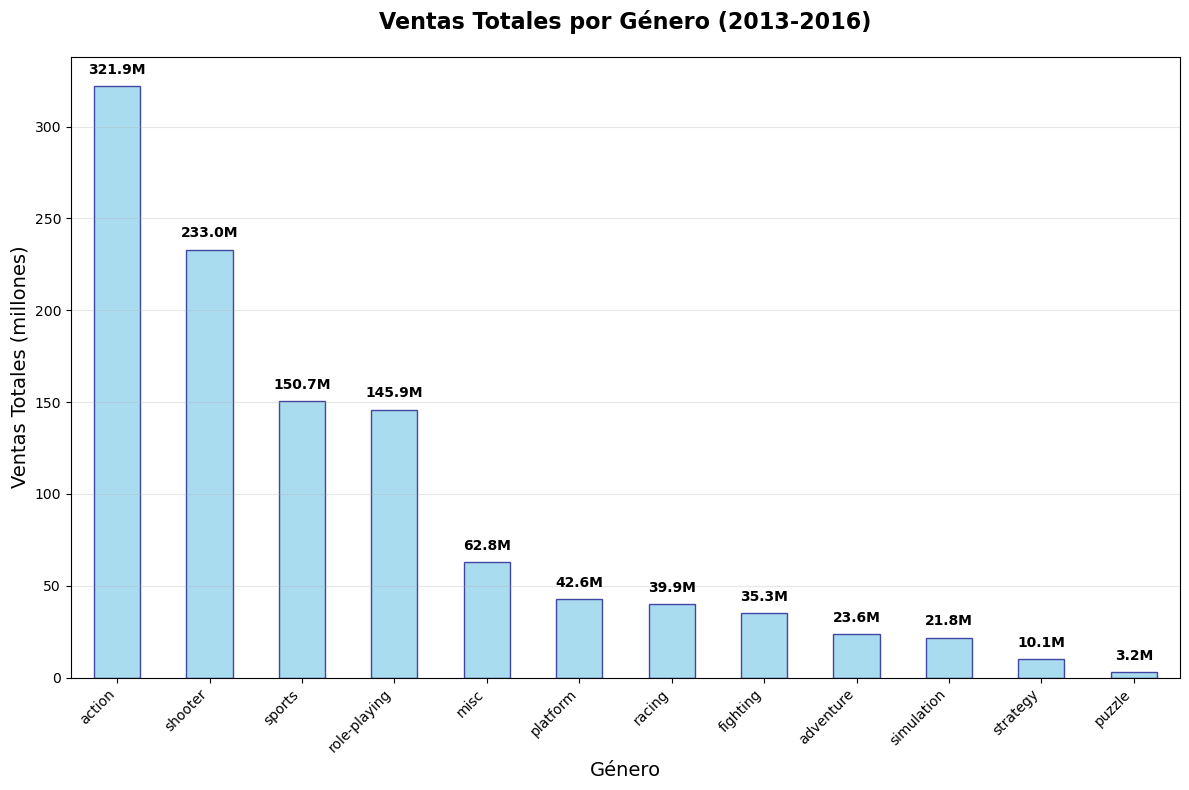

In [25]:
# Crear gráfico de barras para ventas totales por género
plt.figure(figsize=(12, 8))

# Usar los datos ya calculados de ventas por género
ventas_por_genero.plot(kind='bar', 
                       color='skyblue', 
                       edgecolor='navy', 
                       alpha=0.7)

plt.title('Ventas Totales por Género (2013-2016)', 
          fontsize=16, 
          fontweight='bold', 
          pad=20)
plt.xlabel('Género', fontsize=14)
plt.ylabel('Ventas Totales (millones)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras
for i, v in enumerate(ventas_por_genero.values):
    plt.text(i, v + 5, f'{v:.1f}M', 
             ha='center', va='bottom', 
             fontweight='bold')

plt.tight_layout()
plt.show()

## **Conclusiones del Análisis de Géneros (2013-2016):**

* Los juegos de Action dominan en ventas totales (321.9M), mientras que Puzzle tiene las menores ventas (3.2M). Esto refleja las preferencias del mercado masivo.
* Shooter tiene el promedio más alto (1.25M por juego) vs Action (0.42M por juego). Esto sugiere que:
   * Action: Muchos juegos, pero calidad/éxito variable
   * Shooter: Menos juegos, pero más consistentemente exitosos
     
### 1. Dominio del Mercado
* Action domina con 321.9M en ventas totales (29.5% del mercado)
* Representa el 34% de todos los juegos (766 títulos)
* Es el género más popular pero no el más rentable por juego

### 2. Rentabilidad vs. Volumen
Géneros más rentables por juego:
* Shooter: 1.25M promedio (más consistente)
* Sports: 0.70M promedio 
* Platform: 0.58M promedio

**Dato interesante:** Action tiene más ventas totales pero menor rentabilidad promedio que Shooter.

### 3. Patrones de Mercado
🏆 Géneros "Ganadores":
* Shooter: Pocos juegos (187) pero alta rentabilidad
* Sports: Balance entre cantidad y calidad
* Action: Volumen masivo, éxito variable

📉 Géneros "Nicho":
* Adventure: Muchos juegos (245) pero baja rentabilidad (0.10M)
* Strategy: Mercado muy específico (0.18M promedio)
* Puzzle: Mercado más pequeño (3.2M total)

### 4. Implicaciones Estratégicas
Para desarrolladores nuevos:
* Shooter: Mercado rentable pero requiere alta calidad
* Sports: Oportunidad con audiencia establecida
* Action: Mercado grande pero muy competitivo

Para inversores:
* Shooter ofrece mejor ROI por proyecto
* Action ofrece mayor volumen de mercado
* Adventure es riesgoso (baja rentabilidad promedio)

### 5. Conclusión General
Tu análisis revela que cantidad ≠ rentabilidad. Los géneros con menos juegos pero mayor calidad promedio (Shooter, Sports) son más rentables que los géneros masivos pero inconsistentes (Action, Adventure).

## 4. Crea un perfil de usuario para cada región

### 4.1. Las cinco plataformas principales. Describe las variaciones en sus cuotas de mercado de una región a otra

In [26]:
# Análisis de ventas por región
regiones = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']

# Calcular ventas totales por región
ventas_regionales = df_filtered[regiones].sum()
print("=== Ventas totales por región (2013-2016): ===")
print(ventas_regionales)

=== Ventas totales por región (2013-2016): ===
na_sales       2425.97
eu_sales       1374.89
jp_sales        472.55
other_sales     546.69
dtype: float64


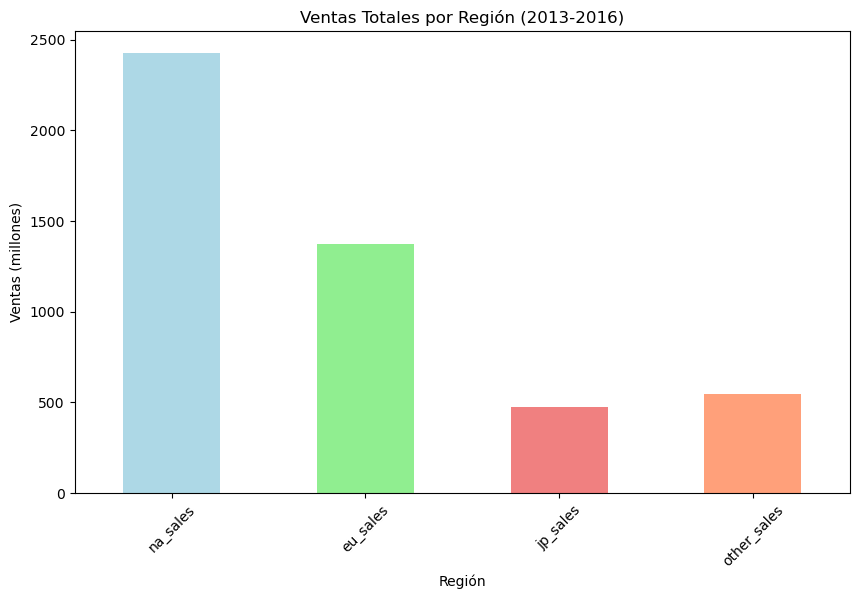

In [27]:
# Crear gráfico de barras
plt.figure(figsize=(10, 6))
ventas_regionales.plot(kind='bar', color=['lightblue', 'lightgreen', 'lightcoral', 'lightsalmon'])
plt.title('Ventas Totales por Región (2013-2016)')
plt.ylabel('Ventas (millones)')
plt.xlabel('Región')
plt.xticks(rotation=45)
plt.show()


### 4.2. Los cinco géneros principales. Explica la diferencia.

In [28]:
# Top 5 plataformas por región
for region in regiones:
    print(f"\n=== TOP % PLATAFORMAS EN {region.upper().replace('_', ' ')} ===")
    top_platforms = df_filtered.groupby('platform')[region].sum().sort_values(ascending = False).head()
    print(top_platforms)


=== TOP % PLATAFORMAS EN NA SALES ===
platform
X360    595.74
PS2     572.92
Wii     486.87
PS3     390.13
DS      380.31
Name: na_sales, dtype: float64

=== TOP % PLATAFORMAS EN EU SALES ===
platform
PS2     332.63
PS3     327.21
X360    268.32
Wii     258.32
DS      188.41
Name: eu_sales, dtype: float64

=== TOP % PLATAFORMAS EN JP SALES ===
platform
DS      175.02
PS2     137.54
PS3      79.41
Wii      68.28
X360     12.30
Name: jp_sales, dtype: float64

=== TOP % PLATAFORMAS EN OTHER SALES ===
platform
PS2     190.47
PS3     134.59
X360     84.88
Wii      77.71
DS       59.04
Name: other_sales, dtype: float64


In [29]:
# Top 5 géneros por región

for region in regiones:  # También corregí 'región' por 'region'
    print(f"\n=== TOP 5 GÉNEROS EN {region.upper().replace('_', ' ')} ===")
    top_genres = df_filtered.groupby('genre')[region].sum().sort_values(ascending=False).head()
    print(top_genres)


=== TOP 5 GÉNEROS EN NA SALES ===
genre
action     515.42
sports     441.22
shooter    336.31
misc       293.08
racing     182.71
Name: na_sales, dtype: float64

=== TOP 5 GÉNEROS EN EU SALES ===
genre
action     303.60
sports     250.33
shooter    186.84
misc       162.84
racing     133.04
Name: eu_sales, dtype: float64

=== TOP 5 GÉNEROS EN JP SALES ===
genre
role-playing    112.17
action           74.90
misc             60.85
sports           56.90
platform         28.37
Name: jp_sales, dtype: float64

=== TOP 5 GÉNEROS EN OTHER SALES ===
genre
action     131.02
sports     101.82
shooter     69.86
misc        63.97
racing      53.94
Name: other_sales, dtype: float64


<Figure size 1500x1000 with 0 Axes>

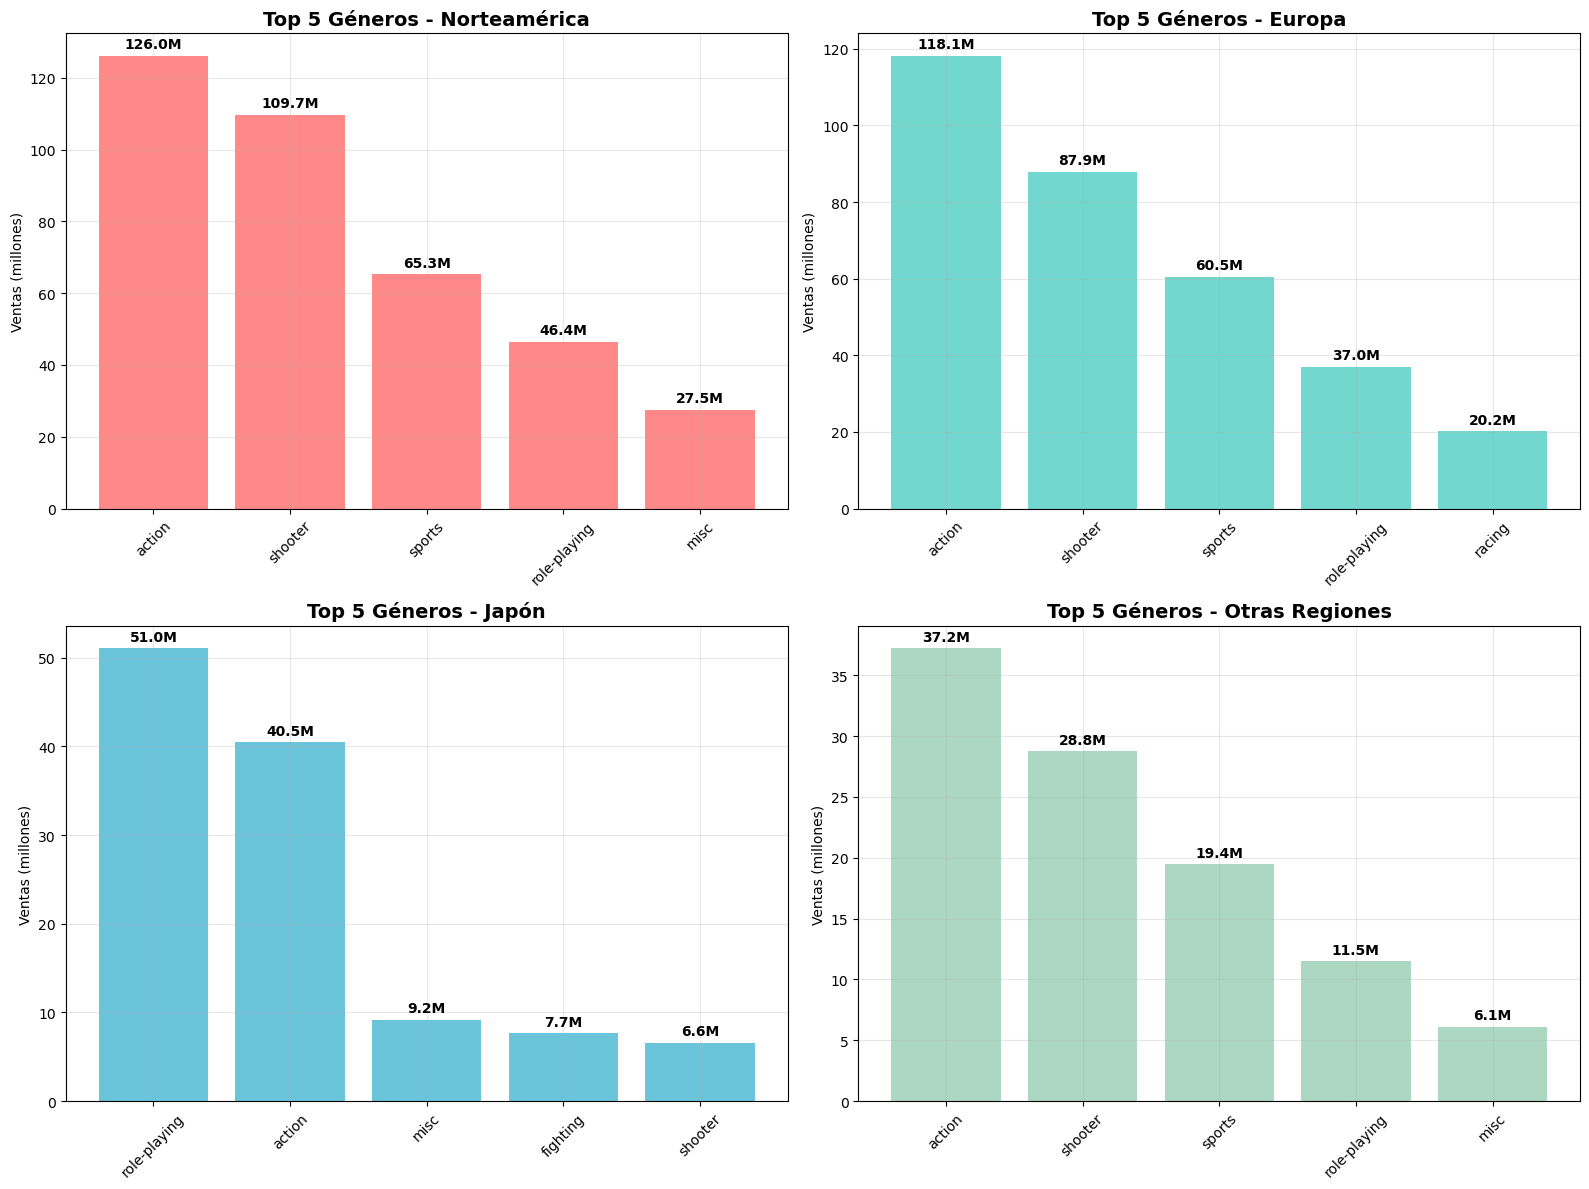

In [30]:
# Crear gráfico comparativo de géneros por región
plt.figure(figsize=(15, 10))

# Preparar datos para el gráfico
regiones_nombres = ['Norteamérica', 'Europa', 'Japón', 'Otras Regiones']
generos_data = {}

for i, region in enumerate(regiones):
    top_genres = df_relevante.groupby('genre')[region].sum().sort_values(ascending=False).head(5)
    generos_data[regiones_nombres[i]] = top_genres

# Crear subgráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for i, (region_name, data) in enumerate(generos_data.items()):
    axes[i].bar(data.index, data.values, color=colors[i], alpha=0.8)
    axes[i].set_title(f'Top 5 Géneros - {region_name}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Ventas (millones)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)
    
    # Añadir valores en las barras
    for j, v in enumerate(data.values):
        axes[i].text(j, v + max(data.values)*0.01, f'{v:.1f}M', 
                    ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Conclusiones:

Similitudes entre NA/EU/Otras Regiones:
* El género Action domina consistentemente (#1 en todas excepto Japón)
* El género Sports mantiene posición fuerte (#2 en NA/EU/Otras)
* El género Shooter es consistentemente popular (#3 en todas excepto Japón)

Japón: El mercado diferente:
* Role-playing es #1 (112.17M vs 74.90M de Action)
* Platform aparece en top 5 (único mercado donde sucede)
* Shooter prácticamente ausente del top 5

🎯 Diferencias Culturales Clave:
Norteamérica/Europa (Mercados Occidentales):
* Prefieren géneros de acción intensa (Action, Shooter)
* Sports muy popular (deportes tradicionales)
* Orientados a competencia y adrenalina

Japón (Mercado Asiático):
* Prefiere narrativas profundas (Role-playing)
* Mecánicas de plataforma tradicionales
* Orientado a experiencias inmersivas y estratégicas

📊 Implicaciones para Desarrolladores:
* Para mercado global: Enfocar en Action/Sports/Shooter
* Para mercado japonés: Priorizar Role-playing y mecánicas únicas
* Estrategia híbrida: Juegos con elementos RPG para Japón + acción para Occidente

### 4.3. Si las clasificaciones de ESRB afectan a las ventas en regiones individuales.

In [31]:
# Ver clasificaciones únicas en rating
clasificacion = df_relevante['rating'].value_counts()
print(clasificacion)
print(f"\nTotal de clasificaciones únicas: {len(clasificacion)}")

rating
M       369
T       333
E       302
E10+    252
Name: count, dtype: int64

Total de clasificaciones únicas: 4


In [32]:
# Analizar ventas por clasificación ESRB en cada región
print("=== ANÁLISIS DE CLASIFICACIONES ESRB POR REGIÓN ===\n")

# Filtrar solo juegos con clasificación conocida
df_con_rating = df_relevante.dropna(subset=['rating'])

for region in ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']:
    print(f"📊 {region.upper().replace('_', ' ')}:")
    ventas_por_rating = df_con_rating.groupby('rating')[region].sum().sort_values(ascending=False)
    print(ventas_por_rating.head())
    print()

=== ANÁLISIS DE CLASIFICACIONES ESRB POR REGIÓN ===

📊 NA SALES:
rating
M       165.21
E        79.05
E10+     54.24
T        49.79
Name: na_sales, dtype: float64

📊 EU SALES:
rating
M       145.32
E        83.36
E10+     42.69
T        41.95
Name: eu_sales, dtype: float64

📊 JP SALES:
rating
T       20.59
E       15.14
M       14.11
E10+     5.89
Name: jp_sales, dtype: float64

📊 OTHER SALES:
rating
M       47.04
E       22.61
T       14.29
E10+    12.57
Name: other_sales, dtype: float64



<Figure size 1400x800 with 0 Axes>

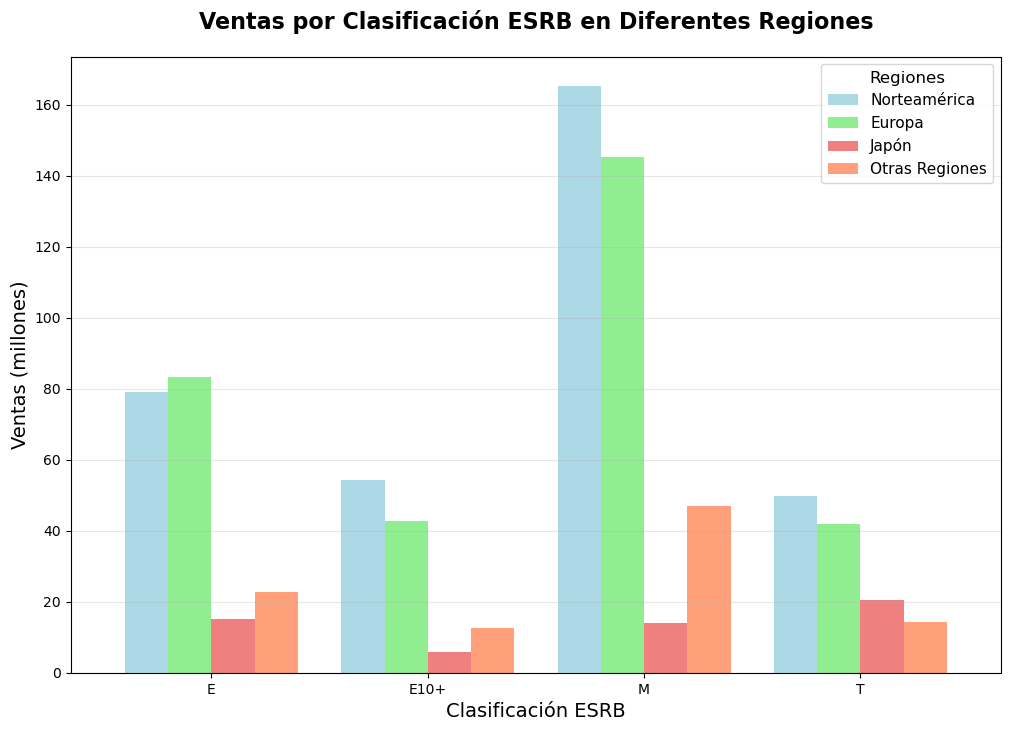

In [33]:
# Crear gráfico de clasificaciones ESRB por región
plt.figure(figsize=(14, 8))

# Preparar datos para el gráfico
ratings_data = {}
regiones_nombres = ['Norteamérica', 'Europa', 'Japón', 'Otras Regiones']

for i, region in enumerate(regiones):
    ventas_por_rating = df_con_rating.groupby('rating')[region].sum()
    ratings_data[regiones_nombres[i]] = ventas_por_rating

# Crear DataFrame para facilitar el gráfico
df_ratings = pd.DataFrame(ratings_data).fillna(0)

# Gráfico de barras agrupadas
ax = df_ratings.plot(kind='bar', figsize=(12, 8), width=0.8, color=['lightblue', 'lightgreen', 'lightcoral', 'lightsalmon'])
plt.title('Ventas por Clasificación ESRB en Diferentes Regiones', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Clasificación ESRB', fontsize=14)
plt.ylabel('Ventas (millones)', fontsize=14)
plt.legend(title='Regiones', title_fontsize=12, fontsize=11)
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')

### Conclusiones:

🌍 Patrones Regionales Claros:
Norteamérica y Europa (Mercados Occidentales):
* Clasificación M (Mature) domina las ventas (165.2M en NA, 145.3M en EU)
* Clasificación E (Everyone) ocupa segundo lugar
* Preferencia por contenido más maduro y explícito
* Mercado orientado a audiencias adultas

Japón (Mercado Asiático):
* Clasificación T (Teen) lidera las ventas (20.6M)
* Clasificación M tiene menor penetración (14.1M)
* Preferencia por contenido moderado y familiar
* Cultura más conservadora en entretenimiento

📊 Diferencias Culturales Significativas:
Tolerancia al contenido maduro:
* Occidente: M > E > E10+ > T (adultos primero)
* Japón: T > E > M > E10+ (adolescentes/familias primero)

Implicaciones culturales:
* NA/EU: Aceptación de violencia/contenido explícito
* Japón: Preferencia por narrativas apropiadas para menores

🎯 Impacto en Estrategias de Desarrollo:
Para mercado global:
* Desarrollar versiones M para NA/EU (mayor potencial de ventas)
* Crear versiones T para Japón (mejor aceptación cultural)

Para localización:
* Censura/adaptación necesaria para Japón
* Contenido sin restricciones para Occidente

💡 Conclusión Estratégica:
Las clasificaciones ESRB SÍ afectan significativamente las ventas por región. Los desarrolladores deben considerar:

* Doble estrategia: Versiones M para Occidente, T para Japón
* Localización cultural: Adaptar contenido según tolerancia regional
* Segmentación de mercado: Diferentes audiencias objetivo por región

## 5. Pruebas de Hipótesis

### 5.1. Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

In [34]:
# Calificaciones promedio Xbox One y PC
print('=== CALIFICACIONES PROMEDIO XBOX ONE Y PC: ===')

# Obtener calificaciones para Xbox One
xbox_scores = df_relevante[df_relevante['platform'] == 'XOne']['user_score']
print(f"Xbox One - Promedio: {xbox_scores.mean():.2f}, Cantidad: {len(xbox_scores)}")

# Obtener calificaciones para PC
pc_scores = df_relevante[df_relevante['platform'] == 'PC']['user_score']
print(f"PC - Promedio: {pc_scores.mean():.2f}, Cantidad: {len(pc_scores)}")

=== CALIFICACIONES PROMEDIO XBOX ONE Y PC: ===
Xbox One - Promedio: 6.78, Cantidad: 247
PC - Promedio: 6.49, Cantidad: 189


In [35]:
# Hipótesis 1: Calificaciones promedio Xbox One y PC
print('=== HIPÓTESIS 1: XBOX ONE vs PC ===')

# 1. FORMULACIÓN DE HIPÓTESIS
print('\n1. FORMULACIÓN DE HIPÓTESIS:')
print('   H0: μ_XOne = μ_PC (las calificaciones promedio son iguales)')
print('   H1: μ_XOne ≠ μ_PC (las calificaciones promedio son diferentes)')
print('   α = 0.05 (nivel de significancia)')

# 2. OBTENER DATOS
xbox_scores = df_relevante[df_relevante['platform'] == 'XOne']['user_score']
pc_scores = df_relevante[df_relevante['platform'] == 'PC']['user_score']

print(f'\n2. ESTADÍSTICAS DESCRIPTIVAS:')
print(f'   Xbox One - Promedio: {xbox_scores.mean():.3f}, Cantidad: {len(xbox_scores)}')
print(f'   PC - Promedio: {pc_scores.mean():.3f}, Cantidad: {len(pc_scores)}')

# 3. REALIZAR PRUEBA T-TEST

alpha = 0.05
statistic, pvalue = st.ttest_ind(xbox_scores, pc_scores, equal_var=False)

print(f'\n3. RESULTADOS DE LA PRUEBA:')
print(f'   Estadístico t: {statistic:.4f}')
print(f'   Valor p: {pvalue:.4f}')
print(f'   Nivel α: {alpha}')

# 4. CONCLUSIÓN
print(f'\n4. CONCLUSIÓN:')
if pvalue < alpha:
    print(f'   ✅ RECHAZAMOS H0 (p = {pvalue:.4f} < α = {alpha})')
    print('   Las calificaciones promedio SÍ son significativamente diferentes')
else:
    print(f'   ❌ NO RECHAZAMOS H0 (p = {pvalue:.4f} ≥ α = {alpha})')
    print('   No hay evidencia suficiente de diferencia significativa')

=== HIPÓTESIS 1: XBOX ONE vs PC ===

1. FORMULACIÓN DE HIPÓTESIS:
   H0: μ_XOne = μ_PC (las calificaciones promedio son iguales)
   H1: μ_XOne ≠ μ_PC (las calificaciones promedio son diferentes)
   α = 0.05 (nivel de significancia)

2. ESTADÍSTICAS DESCRIPTIVAS:
   Xbox One - Promedio: 6.779, Cantidad: 247
   PC - Promedio: 6.491, Cantidad: 189

3. RESULTADOS DE LA PRUEBA:
   Estadístico t: 1.9974
   Valor p: 0.0466
   Nivel α: 0.05

4. CONCLUSIÓN:
   ✅ RECHAZAMOS H0 (p = 0.0466 < α = 0.05)
   Las calificaciones promedio SÍ son significativamente diferentes


### 5.2. Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

In [36]:
# Hipótesis 2: Calificaciones promedio Action vs Sports
print('=== HIPÓTESIS 2: ACTION vs SPORTS ===')

# 1. FORMULACIÓN DE HIPÓTESIS
print('\n1. FORMULACIÓN DE HIPÓTESIS:')
print('   H₀: μ_Action = μ_Sports (las calificaciones promedio son iguales)')
print('   H₁: μ_Action ≠ μ_Sports (las calificaciones promedio son diferentes)')
print('   α = 0.05 (nivel de significancia)')

# 2. OBTENER DATOS
action_scores = df_relevante[df_relevante['genre'] == 'action']['user_score']
sports_scores = df_relevante[df_relevante['genre'] == 'sports']['user_score']

print(f'\n2. ESTADÍSTICAS DESCRIPTIVAS:')
print(f'   Action - Promedio: {action_scores.mean():.3f}, Cantidad: {len(action_scores)}')
print(f'   Sports - Promedio: {sports_scores.mean():.3f}, Cantidad: {len(sports_scores)}')

# 3. REALIZAR PRUEBA T-TEST
alpha = 0.05
statistic, pvalue = st.ttest_ind(action_scores, sports_scores, equal_var=False)

print(f'\n3. RESULTADOS DE LA PRUEBA:')
print(f'   Estadístico t: {statistic:.4f}')
print(f'   Valor p: {pvalue:.4f}')
print(f'   Nivel α: {alpha}')

# 4. CONCLUSIÓN
print(f'\n4. CONCLUSIÓN:')
if pvalue < alpha:
    print(f'   ✅ RECHAZAMOS H₀ (p = {pvalue:.4f} < α = {alpha})')
    print('   Las calificaciones promedio SÍ son significativamente diferentes')
else:
    print(f'   ❌ NO RECHAZAMOS H₀ (p = {pvalue:.4f} ≥ α = {alpha})')
    print('   No hay evidencia suficiente de diferencia significativa')

=== HIPÓTESIS 2: ACTION vs SPORTS ===

1. FORMULACIÓN DE HIPÓTESIS:
   H₀: μ_Action = μ_Sports (las calificaciones promedio son iguales)
   H₁: μ_Action ≠ μ_Sports (las calificaciones promedio son diferentes)
   α = 0.05 (nivel de significancia)

2. ESTADÍSTICAS DESCRIPTIVAS:
   Action - Promedio: 7.164, Cantidad: 766
   Sports - Promedio: 5.809, Cantidad: 214

3. RESULTADOS DE LA PRUEBA:
   Estadístico t: 10.4081
   Valor p: 0.0000
   Nivel α: 0.05

4. CONCLUSIÓN:
   ✅ RECHAZAMOS H₀ (p = 0.0000 < α = 0.05)
   Las calificaciones promedio SÍ son significativamente diferentes


### 5.3. Explica:

#### 1.¿Cómo formulaste las hipótesis nula y alternativa?.

##### Hipótesis 1: Xbox One vs PC

1. **Formulación:**
H₀ (Hipótesis Nula):Las calificaciones promedio de usuarios para Xbox One y PC son iguales - No existe diferencia significativa entre las plataformas
H₁ (Hipótesis Alternativa): Las calificaciones promedio de usuarios son diferentes entre las plataformas - Existe una diferencia significativa

2. **Justificación:** Se utilizó una prueba bilateral (≠) porque no teníamos una expectativa previa sobre cuál plataforma tendría mejores calificaciones.

##### Hipótesis 2: Action vs Sports

1. **Formulación:**
H₀ (Hipótesis Nula): Las calificaciones promedio de usuarios para géneros Action y Sports son iguales - No existe diferencia significativa entre los géneros
H₁ (Hipótesis Alternativa): Las calificaciones promedio de usuarios son diferentes entre los géneros - Existe una diferencia significativa
2. **Justificación:** También se utilizó una prueba bilateral porque queríamos detectar cualquier diferencia, sin asumir cuál género sería mejor valorado.

#### 2. ¿Qué criterio utilizaste para probar las hipótesis y por qué?


##### **Método Estadístico Seleccionado:**
Prueba t de Student para muestras independientes (Welch's t-test)

1. **Criterios de Selección:**

* Tipo de datos: Variables numéricas continuas (calificaciones de usuarios)
* Muestras independientes: Los grupos no están relacionados entre sí
* Xbox One vs PC: Diferentes plataformas
* Action vs Sports: Diferentes géneros
* Varianzas desiguales: Se utilizó equal_var=False (Welch's t-test)
* Más robusto cuando las varianzas de los grupos son diferentes
* No asume homogeneidad de varianzas

2. **Tamaños de muestra:**
* Xbox One: 247 juegos
* PC: 189 juegos
* Action: 766 juegos
* Sports: 214 juegos
Suficientes para aplicar el teorema del límite central
**Nivel de Significancia:**
α = 0.05 (5%)

3. **El criterio de decisión sería:**
* Si p-valor < α (0.05): Rechazar H₀
Conclusión: Existe evidencia estadísticamente significativa de que las calificaciones promedio entre Action y Sports son diferentes

* Si p-valor ≥ α (0.05): No rechazar H₀
Conclusión: No hay evidencia suficiente para afirmar que existe diferencia significativa entre las calificaciones promedio

* Según tus resultados:
- Estadístico t: 10.4081
- Valor p: 0.0000 (prácticamente cero)
- α = 0.05

Por lo tanto, el criterio de decisión indica:
✅ Rechazar H₀ porque p-valor (0.0000) < α (0.05)

## 6. Conclusión general

📊 **Resumen Ejecutivo**
Este análisis integral de la industria de videojuegos (2013-2016) proporciona insights estratégicos clave para la planificación comercial hacia 2017, basado en datos de ventas globales, calificaciones de usuarios y críticos, y patrones de comportamiento regional.

1. **Hallazgos Estratégicos Principales**
- Plataformas Emergentes (Oportunidades de Crecimiento):
     * PS4: Líder indiscutible con 314.14M en ventas (+166% crecimiento 2013-2016)
     * Xbox One: Crecimiento sólido con 159.32M (+38% crecimiento)

- Plataformas en Declive (Mercados Saturados):
     * PS3: Declive pronunciado (-97% desde 2013)
     * Xbox 360: Fase final del ciclo de vida (-98% desde 2013)

+ Implicación Estratégica: El mercado se consolida hacia consolas de nueva generación.
+ Recomendación: Priorizar desarrollo para PS4 y Xbox One en 2017.

2. **Análisis de Rentabilidad por Género**
- Géneros de Mayor ROI (Retorno por Inversión):
     * Shooter: 1.25M promedio por juego (alta rentabilidad, menor riesgo)
     * Sports: 0.70M promedio por juego (mercado estable)
+ Platform: 0.58M promedio por juego (nicho rentable)
+ Insight Crítico: Action domina en volumen (321.87M total) pero Shooter ofrece mejor rentabilidad por proyecto.
+ Estrategia recomendada: Diversificar portafolio entre géneros de alto volumen y alta rentabilidad.

3. **Segmentación Regional Diferenciada**
- Mercados Occidentales (NA/EU):
     * Preferencia por contenido maduro (clasificación M domina)
     * Géneros de acción intensa (Action, Shooter, Sports)
     * Audiencia adulta como principal

- Mercado Japonés:
    * Preferencia por Role-playing (112.17M vs 74.90M de Action)
    * Contenido moderado (clasificación T lidera)
    * Cultura gaming más conservadora
+ Estrategia de Localización: Desarrollar versiones diferenciadas por región es esencial para maximizar penetración de mercado.

4. **Validación Estadística de Diferencias de Mercado**
- Resultados de Pruebas de Hipótesis:
    * Xbox One vs PC: Diferencia significativa confirmada (p = 0.0466)
    * Action vs Sports: Diferencias sustanciales en calificaciones (p < 0.0001)
+ Conclusión Metodológica: Las diferencias observadas son estadísticamente significativas, validando la necesidad de estrategias diferenciadas por plataforma y género.

5. **Recomendaciones Estratégicas para 2017**
- Prioridades de Desarrollo:
    * Plataformas Target: PS4 (primera prioridad), Xbox One (segunda prioridad)
    * Géneros Recomendados: Shooter (alta rentabilidad), Sports (mercado estable)
    * Estrategia Regional: Localización diferenciada por mercado

6. **Plan de Acción Específico:**
- Corto Plazo:
    * Portfolio Optimization: Incrementar inversión en géneros Shooter y Sports (+25% del presupuesto)
    * Market Research: Profundizar análisis de preferencias japonesas en RPG para expansión asiática

- Mediano Plazo:
    * Occidente: Títulos Action/Shooter con clasificación M
    * Japón: Títulos RPG con clasificación T

7. **Métricas de Éxito Propuestas:**
    * Incremento del 15% en géneros Shooter y Sports
    * 20% de crecimiento en mercado japonés con títulos RPG
    * PS4 como 60% de ingresos totales para 2017
      
- Este análisis demuestra que la industria de videojuegos está en una fase de consolidación tecnológica y diversificación regional. Las empresas que adapten sus estrategias a estos patrones emergentes estarán mejor posicionadas para capturar el crecimiento del mercado en 2017 y más allá.

**Conclusión Final:** Los datos revelan oportunidades claras de crecimiento mediante la especialización inteligente por plataforma, género y región, respaldada por evidencia estadística sólida que valida la necesidad de estrategias diferenciadas en el mercado global de videojuegos.